In [2]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# 1. NẠP DỮ LIỆU
df = pd.read_excel("data.xlsx")
# Giả sử bạn lấy dữ liệu cho toàn bộ giai đoạn 1990 - 2023
df_pre = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
# Khắc phục biến LF nếu có trống
df_pre['LF'] = df_pre['LF'].bfill()

print("="*60)
print("1. BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (1990 - 2023)")
print("="*60)
# Chọn các biến chính để thống kê
desc_stats = df_pre[['TF', 'UP', 'LF']].describe().round(3)
print(desc_stats.loc[['count', 'mean', 'std', 'min', 'max']])

print("\n" + "="*60)
print("2. KIỂM ĐỊNH TÍNH DỪNG AUGMENTED DICKEY-FULLER (ADF TEST)")
print("="*60)

# Hàm chạy ADF và in kết quả gọn gàng
def run_adf_test(series, var_name):
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = "Dừng (Stationary)" if p_value < 0.05 else "Không dừng (Non-stationary)"
    print(f"Biến {var_name: <15} | P-value: {p_value:.4f} | Kết luận: {is_stationary}")

# Chạy kiểm định cho chuỗi GỐC (Level)
print("--- A. Chuỗi dữ liệu gốc (Level) ---")
run_adf_test(df_pre['TF'], "TF (Tỷ suất sinh)")
run_adf_test(df_pre['UP'], "UP (Đô thị hóa)")
run_adf_test(df_pre['LF'], "LF (Lao động nữ)")

# Chạy kiểm định cho chuỗi SAI PHÂN BẬC 1 (First Difference)
print("\n--- B. Chuỗi sau khi lấy sai phân bậc 1 (1st Difference) ---")
run_adf_test(df_pre['TF'].diff(), "d_TF")
run_adf_test(df_pre['UP'].diff(), "d_UP")
run_adf_test(df_pre['LF'].diff(), "d_LF")

1. BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (1990 - 2023)
           TF      UP      LF
count  34.000  34.000  34.000
mean    2.212  28.073  49.321
std     0.504   5.612   0.484
min     1.873  19.174  48.097
max     3.602  38.130  50.045

2. KIỂM ĐỊNH TÍNH DỪNG AUGMENTED DICKEY-FULLER (ADF TEST)
--- A. Chuỗi dữ liệu gốc (Level) ---
Biến TF (Tỷ suất sinh) | P-value: 0.0002 | Kết luận: Dừng (Stationary)
Biến UP (Đô thị hóa) | P-value: 0.9929 | Kết luận: Không dừng (Non-stationary)
Biến LF (Lao động nữ) | P-value: 0.6891 | Kết luận: Không dừng (Non-stationary)

--- B. Chuỗi sau khi lấy sai phân bậc 1 (1st Difference) ---
Biến d_TF            | P-value: 0.2939 | Kết luận: Không dừng (Non-stationary)
Biến d_UP            | P-value: 0.1366 | Kết luận: Không dừng (Non-stationary)
Biến d_LF            | P-value: 0.0001 | Kết luận: Dừng (Stationary)


In [3]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_excel("data.xlsx")
# Tính sai phân bậc 2 cho UP
d2_UP = df['UP'].diff().diff().dropna()

print("Kiểm định ADF cho d2_UP (Sai phân bậc 2 của Đô thị hóa):")
print(f"P-value: {adfuller(d2_UP)[1]:.4f}")

Kiểm định ADF cho d2_UP (Sai phân bậc 2 của Đô thị hóa):
P-value: 0.1712


In [1]:
import pandas as pd
from statsmodels.tsa.stattools import kpss
import warnings
warnings.filterwarnings("ignore")

# 1. NẠP DỮ LIỆU
df = pd.read_excel("data.xlsx")

# 2. TẠO BIẾN SAI PHÂN BẬC 1 CHO ĐÔ THỊ HÓA
d_UP = df['UP'].diff().dropna()

print("="*60)
print("KIỂM ĐỊNH TÍNH DỪNG KPSS CHO SAI PHÂN BẬC 1 (d_UP)")
print("="*60)

# Chạy kiểm định KPSS
kpss_stat, p_value, lags, crit = kpss(d_UP, regression='c')

print(f"Giá trị P-value của KPSS: {p_value:.4f}")

if p_value > 0.05:
    print("-> Kết luận: Bác bỏ hoàn toàn nỗi lo! Chuỗi d_UP ĐÃ DỪNG ở mức ý nghĩa 5%.")
else:
    print("-> Kết luận: Chuỗi vẫn chưa dừng theo KPSS.")

KIỂM ĐỊNH TÍNH DỪNG KPSS CHO SAI PHÂN BẬC 1 (d_UP)
Giá trị P-value của KPSS: 0.0535
-> Kết luận: Bác bỏ hoàn toàn nỗi lo! Chuỗi d_UP ĐÃ DỪNG ở mức ý nghĩa 5%.


In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# 1. NẠP VÀ XỬ LÝ DỮ LIỆU
df = pd.read_excel("data.xlsx")
df_pre = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
df_pre['LF'] = df_pre['LF'].bfill()

# Xử lý biến GDP (Logarit, Sai phân bậc 1, Sai phân bậc 2)
df_pre['Ln_GDP'] = np.log(df_pre['GDP'])
df_pre['d_Ln_GDP'] = df_pre['Ln_GDP'].diff()
df_pre['d2_Ln_GDP'] = df_pre['d_Ln_GDP'].diff()

print("="*60)
print("1. BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (1990 - 2023)")
print("="*60)
# Thêm GDP vào thống kê
desc_stats = df_pre[['TF', 'UP', 'LF', 'GDP']].describe().round(3)
print(desc_stats.loc[['count', 'mean', 'std', 'min', 'max']])

print("\n" + "="*60)
print("2. KIỂM ĐỊNH TÍNH DỪNG AUGMENTED DICKEY-FULLER (ADF TEST)")
print("="*60)

# Hàm chạy ADF và in kết quả gọn gàng
def run_adf_test(series, var_name):
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = "Dừng (Stationary)" if p_value < 0.05 else "Không dừng (Non-stationary)"
    print(f"Biến {var_name: <15} | P-value: {p_value:.4f} | Kết luận: {is_stationary}")

# Chạy kiểm định cho chuỗi GỐC (Level)
print("--- A. Chuỗi dữ liệu gốc (Level) ---")
run_adf_test(df_pre['TF'], "TF (Tỷ suất sinh)")
run_adf_test(df_pre['UP'], "UP (Đô thị hóa)")
run_adf_test(df_pre['LF'], "LF (Lao động nữ)")
run_adf_test(df_pre['Ln_GDP'], "Ln_GDP (Logarit GDP)")

# Chạy kiểm định cho chuỗi SAI PHÂN BẬC 1 (First Difference)
print("\n--- B. Chuỗi sau khi lấy sai phân bậc 1 (1st Difference) ---")
run_adf_test(df_pre['TF'].diff(), "d_TF")
run_adf_test(df_pre['UP'].diff(), "d_UP")
run_adf_test(df_pre['LF'].diff(), "d_LF")
run_adf_test(df_pre['d_Ln_GDP'], "d_Ln_GDP (Tốc độ tăng GDP)")

# Chạy kiểm định cho chuỗi SAI PHÂN BẬC 2 (Second Difference)
print("\n--- C. Chuỗi sau khi lấy sai phân bậc 2 (2nd Difference) ---")
run_adf_test(df_pre['d2_Ln_GDP'], "d2_Ln_GDP (Gia tốc GDP)")

1. BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (1990 - 2023)
           TF      UP      LF       GDP
count  34.000  34.000  34.000    34.000
mean    2.212  28.073  49.321  1501.812
std     0.504   5.612   0.484  1356.101
min     1.873  19.174  48.097    98.798
max     3.602  38.130  50.045  4323.350

2. KIỂM ĐỊNH TÍNH DỪNG AUGMENTED DICKEY-FULLER (ADF TEST)
--- A. Chuỗi dữ liệu gốc (Level) ---
Biến TF (Tỷ suất sinh) | P-value: 0.0002 | Kết luận: Dừng (Stationary)
Biến UP (Đô thị hóa) | P-value: 0.9929 | Kết luận: Không dừng (Non-stationary)
Biến LF (Lao động nữ) | P-value: 0.6891 | Kết luận: Không dừng (Non-stationary)
Biến Ln_GDP (Logarit GDP) | P-value: 0.6084 | Kết luận: Không dừng (Non-stationary)

--- B. Chuỗi sau khi lấy sai phân bậc 1 (1st Difference) ---
Biến d_TF            | P-value: 0.2939 | Kết luận: Không dừng (Non-stationary)
Biến d_UP            | P-value: 0.1366 | Kết luận: Không dừng (Non-stationary)
Biến d_LF            | P-value: 0.0001 | Kết luận: Dừng (Stationary)
Biến d_Ln_GD

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. NẠP DỮ LIỆU TỪ FILE EXCEL
df = pd.read_excel("data.xlsx")

# 2. TIỀN XỬ LÝ CHO MÔ HÌNH 1
# Khắc phục biến LF bị trống trước năm 1990 bằng Backward Fill
df['LF'] = df['LF'].bfill()

# Tạo biến giả Chính sách (Thắt chặt từ 1993)
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Tạo các biến Logarit và Sai phân để đạt tính dừng
df['Ln_GDP'] = np.log(df['GDP'])
df['d_Ln_GDP'] = df['Ln_GDP'].diff()
df['d2_Ln_GDP'] = df['d_Ln_GDP'].diff() # Gia tốc GDP
df['d_LF'] = df['LF'].diff()            # Sai phân tỷ lệ lao động nữ

# 3. LỌC DỮ LIỆU VÀ CHẠY MÔ HÌNH 1 (1987 - 2023)
# Xóa các dòng bị trống (NaN) sinh ra do lấy sai phân
df_m1 = df.dropna(subset=['TF', 'Policy_1993', 'd2_Ln_GDP', 'd_LF']).copy()

print("\n" + "="*60)
print("KẾT QUẢ MÔ HÌNH 1: TÁC ĐỘNG LỊCH SỬ CỦA CHÍNH SÁCH (1987-2023)")
print("="*60)

Y1 = df_m1['TF']
X1 = df_m1[['Policy_1993', 'd2_Ln_GDP', 'd_LF']]
X1 = sm.add_constant(X1)

# Ước lượng OLS với sai số chuẩn Newey-West (HAC)
model1 = sm.OLS(Y1, X1).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(model1.summary())


KẾT QUẢ MÔ HÌNH 1: TÁC ĐỘNG LỊCH SỬ CỦA CHÍNH SÁCH (1987-2023)
                            OLS Regression Results                            
Dep. Variable:                     TF   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     143.5
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           5.27e-19
Time:                        14:53:55   Log-Likelihood:                -6.0139
No. Observations:                  37   AIC:                             20.03
Df Residuals:                      33   BIC:                             26.47
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------


KẾT QUẢ MÔ HÌNH 2 (CÓ ĐỘ TRỄ 1 NĂM): TÁC ĐỘNG SAU 1 NĂM
                            OLS Regression Results                            
Dep. Variable:                     TF   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     1.527
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.242
Time:                        15:10:26   Log-Likelihood:                 34.361
No. Observations:                  22   AIC:                            -60.72
Df Residuals:                      18   BIC:                            -56.36
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

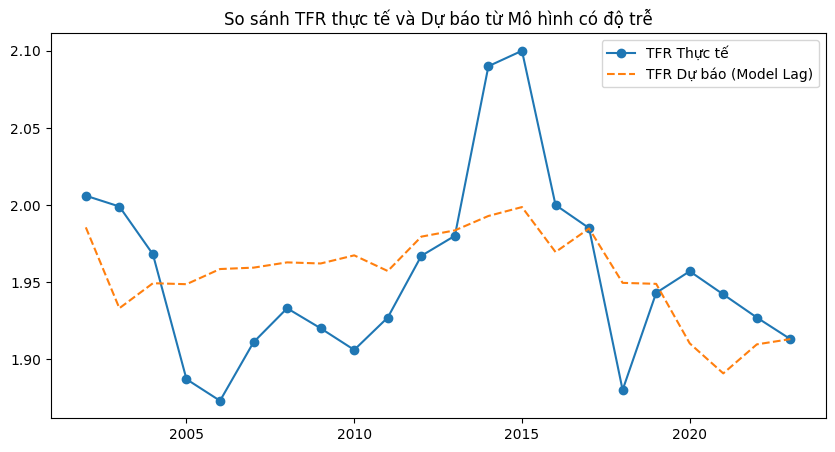

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. TẠO BIẾN ĐỘ TRỄ (LAG) 1 NĂM
# shift(1) sẽ lấy giá trị của năm trước đó gán cho năm hiện tại
df['d_UP_lag1'] = df['d_UP'].shift(1)
df['d_Hexp_lag1'] = df['d_Hexp'].shift(1)
df['d_LF_lag1'] = df['d_LF'].shift(1)

# 2. LỌC DỮ LIỆU GIAI ĐOẠN 2001 - 2023
# Sau khi lấy lag, năm 2001 sẽ bị trống do không có lag của 2000, 
# nên dữ liệu thực tế sẽ chạy từ 2002.
df_m2_lag = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)].copy()
df_m2_lag = df_m2_lag.dropna(subset=['TF', 'd_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1'])

# 3. CHẠY HỒI QUY MÔ HÌNH 2 VỚI ĐỘ TRỄ
print("\n" + "="*70)
print("KẾT QUẢ MÔ HÌNH 2 (CÓ ĐỘ TRỄ 1 NĂM): TÁC ĐỘNG SAU 1 NĂM")
print("="*70)

Y2_lag = df_m2_lag['TF']
# Chúng ta thử dùng các biến có độ trễ để xem tác động muộn
X2_lag = df_m2_lag[['d_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1']]
X2_lag = sm.add_constant(X2_lag)

model2_lag = sm.OLS(Y2_lag, X2_lag).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(model2_lag.summary())

# 4. VẼ BIỂU ĐỒ SO SÁNH (TÙY CHỌN)
plt.figure(figsize=(10, 5))
plt.plot(df_m2_lag['Year'], Y2_lag, label='TFR Thực tế', marker='o')
plt.plot(df_m2_lag['Year'], model2_lag.predict(X2_lag), label='TFR Dự báo (Model Lag)', linestyle='--')
plt.title("So sánh TFR thực tế và Dự báo từ Mô hình có độ trễ")
plt.legend()
plt.show()

In [7]:
!pip install pmdarima


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


--- ĐANG HUẤN LUYỆN THUẬT TOÁN AUTO-ARIMAX ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   34
Model:               SARIMAX(0, 2, 0)   Log Likelihood                  42.778
Date:                Thu, 02 Apr 2026   AIC                            -83.557
Time:                        15:20:48   BIC                            -82.091
Sample:                             0   HQIC                           -83.071
                                 - 34                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0040      0.001      4.215      0.000       0.002       0.006
Ljung-Box (L1) (Q):                   1.84   Jarque-Bera (JB):                 1.44


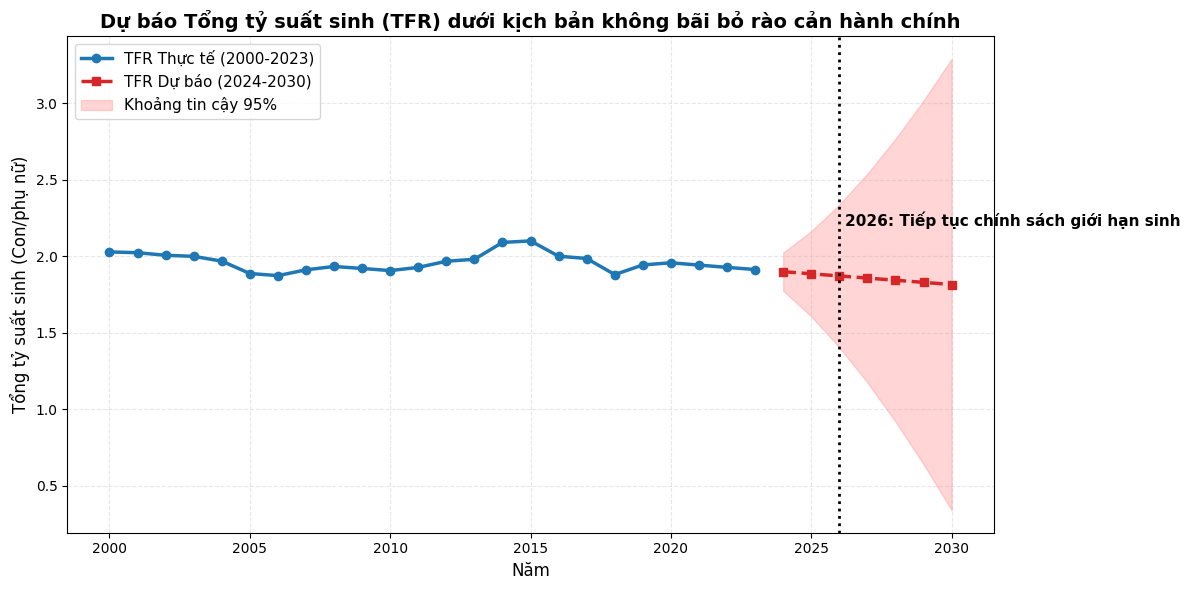


--- SỐ LIỆU TFR DỰ BÁO (2024 - 2030) ---
 Năm  TFR_Dự_báo
2024       1.899
2025       1.885
2026       1.871
2027       1.857
2028       1.843
2029       1.829
2030       1.815


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

# 1. NẠP VÀ CHUẨN BỊ DỮ LIỆU HUẤN LUYỆN (TRAIN DATA)
df = pd.read_excel("data.xlsx")

# Tạo biến giả Chính sách như cũ
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Lấy dữ liệu từ 1990 đến 2023 để huấn luyện thuật toán
train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

# Khai báo biến dự báo (y) và biến ngoại sinh (exog)
y_train = train_df['TF']
# Chúng ta dùng Policy (để xem tác động khi bãi bỏ) và UP (để xem áp lực đô thị)
exog_train = train_df[['Policy_1993', 'UP']] 

print("--- ĐANG HUẤN LUYỆN THUẬT TOÁN AUTO-ARIMAX ---")
# auto_arima sẽ tự động dò tìm bậc (p, d, q) tối ưu nhất cho chuỗi thời gian
model_arimax = auto_arima(y_train, exogenous=exog_train,
                          seasonal=False, stepwise=True, 
                          trace=False, error_action="ignore", suppress_warnings=True)
print(model_arimax.summary())

# 2. XÂY DỰNG KỊCH BẢN DỰ BÁO (2024 - 2030)
future_years = np.arange(2024, 2031)

# Kịch bản Chính sách: 2024-2025 vẫn giữ (1), từ 2026 bãi bỏ hoàn toàn (0)
future_policy = [1, 1, 0, 0, 0, 0, 0]

# Kịch bản Đô thị hóa (UP): Giả định tiếp tục tăng dựa trên tốc độ trung bình 5 năm cuối
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up)) # Tốc độ tăng trung bình hàng năm
last_up = train_df['UP'].iloc[-1]
future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# Ghép thành bảng dữ liệu tương lai
future_exog = pd.DataFrame({
    'Policy_1993': future_policy,
    'UP': future_up
}, index=future_years)

# 3. THỰC HIỆN DỰ BÁO
forecast, conf_int = model_arimax.predict(n_periods=7, exogenous=future_exog, return_conf_int=True)

# 4. TRỰC QUAN HÓA KẾT QUẢ DỰ BÁO (VẼ BIỂU ĐỒ)
plt.figure(figsize=(12, 6))

# Vẽ đường thực tế (Chỉ lấy từ năm 2000 cho dễ nhìn)
plot_df = train_df[train_df['Year'] >= 2000]
plt.plot(plot_df['Year'], plot_df['TF'], label='TFR Thực tế (2000-2023)', color='#1f77b4', linewidth=2.5, marker='o')

# Vẽ đường dự báo
plt.plot(future_years, forecast, label='TFR Dự báo (2024-2030)', color='#d62728', linestyle='--', linewidth=2.5, marker='s')

# Vẽ khoảng tin cậy 95%
plt.fill_between(future_years, conf_int[:, 0], conf_int[:, 1], color='#ff9896', alpha=0.4, label='Khoảng tin cậy 95%')

# Đánh dấu cột mốc lịch sử 2026
plt.axvline(x=2026, color='black', linestyle=':', linewidth=2)
plt.text(2026.2, max(y_train[-10:])+0.1, '2026: Tiếp tục chính sách giới hạn sinh', fontsize=11, fontweight='bold', color='black')

plt.title('Dự báo Tổng tỷ suất sinh (TFR) dưới kịch bản không bãi bỏ rào cản hành chính', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tổng tỷ suất sinh (Con/phụ nữ)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
plt.tight_layout()

# Lưu ảnh cực nét để dán vào Word
plt.savefig("Forecast_ARIMAX_2030.png", dpi=300)
plt.show()

# In kết quả số liệu để đưa vào bảng
forecast_df = pd.DataFrame({'Năm': future_years, 'TFR_Dự_báo': forecast.round(3)})
print("\n--- SỐ LIỆU TFR DỰ BÁO (2024 - 2030) ---")
print(forecast_df.to_string(index=False))


KẾT QUẢ HUẤN LUYỆN ARIMAX (CÓ BIẾN CHÍNH SÁCH VÀ ĐÔ THỊ HÓA)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   34
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  47.462
Date:                Thu, 02 Apr 2026   AIC                            -82.925
Time:                        15:18:47   BIC                            -73.766
Sample:                             0   HQIC                           -79.801
                                 - 34                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.2197      0.154      1.426      0.154      -0.082       0.522
Policy_1993     0.0199      0.067      0.297      0.766      -0.11

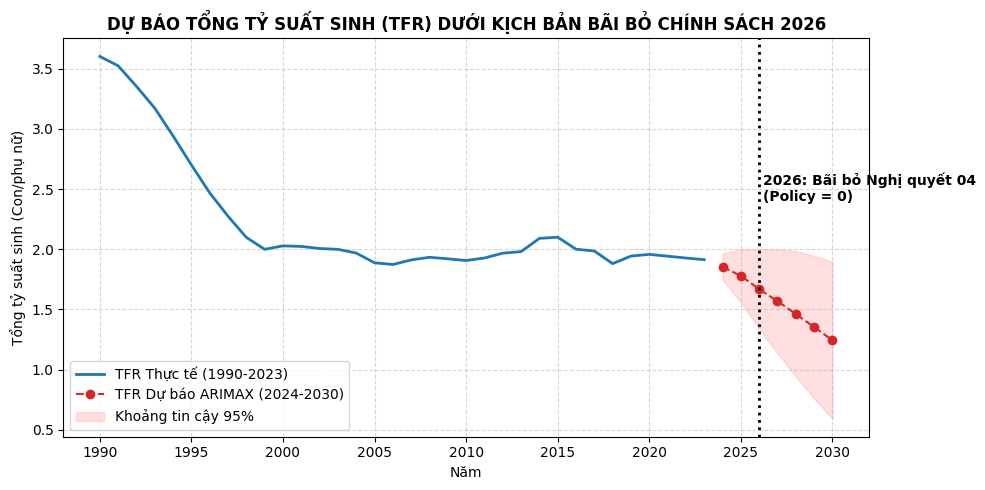


--- BẢNG SỐ LIỆU DỰ BÁO ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.855
2025                1                 39.883       1.778
2026                0                 40.759       1.668
2027                0                 41.636       1.568
2028                0                 42.512       1.462
2029                0                 43.389       1.353
2030                0                 44.265       1.244


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore") # Tắt các cảnh báo đỏ cho gọn kết quả

# 1. NẠP VÀ CHUẨN BỊ DỮ LIỆU
df = pd.read_excel("data.xlsx")

# Tạo biến giả Chính sách (1 từ 1993, 0 trước đó)
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Lấy dữ liệu huấn luyện từ 1990 - 2023
train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

# Khai báo Y và các biến X (Ngoại sinh)
y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']] 

# 2. HUẤN LUYỆN MÔ HÌNH ARIMAX (Có biến ngoại sinh)
print("\n" + "="*70)
print("KẾT QUẢ HUẤN LUYỆN ARIMAX (CÓ BIẾN CHÍNH SÁCH VÀ ĐÔ THỊ HÓA)")
print("="*70)

# Thuật toán tự dò tìm cấu trúc tốt nhất
model_arimax = auto_arima(y_train, X=X_train, 
                          seasonal=False, stepwise=True, 
                          trace=False, suppress_warnings=True)
print(model_arimax.summary())

# 3. THIẾT LẬP KỊCH BẢN TƯƠNG LAI (2024 - 2030)
future_years = np.arange(2024, 2031)

# Kịch bản Chính sách: Giữ nguyên 2024-2025 (1), bãi bỏ hoàn toàn từ 2026 (0)
future_policy = [1, 1, 0, 0, 0, 0, 0]

# Kịch bản Đô thị hóa: Giả định tăng trung bình 0.5% - 0.7%/năm dựa trên quán tính cũ
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up)) 
last_up = train_df['UP'].iloc[-1]
future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# Tạo ma trận biến ngoại sinh cho tương lai
X_future = pd.DataFrame({'Policy_1993': future_policy, 'UP': future_up}, index=future_years)

# 4. THỰC HIỆN DỰ BÁO
forecast, conf_int = model_arimax.predict(n_periods=7, X=X_future, return_conf_int=True)

# 5. VẼ BIỂU ĐỒ DỰ BÁO TRỰC QUAN
plt.figure(figsize=(10, 5))

# TFR Thực tế
plt.plot(train_df['Year'], train_df['TF'], label='TFR Thực tế (1990-2023)', color='#1f77b4', linewidth=2)

# TFR Dự báo
plt.plot(future_years, forecast, label='TFR Dự báo ARIMAX (2024-2030)', color='#d62728', linestyle='--', marker='o')

# Vẽ vùng tin cậy 95%
plt.fill_between(future_years, conf_int[:, 0], conf_int[:, 1], color='#ff9896', alpha=0.3, label='Khoảng tin cậy 95%')

# Đánh dấu năm bãi bỏ chính sách (2026)
plt.axvline(x=2026, color='black', linestyle=':', linewidth=2)
plt.text(2026.2, max(y_train[-10:])+0.3, '2026: Bãi bỏ Nghị quyết 04\n(Policy = 0)', fontsize=10, fontweight='bold')

plt.title('DỰ BÁO TỔNG TỶ SUẤT SINH (TFR) DƯỚI KỊCH BẢN BÃI BỎ CHÍNH SÁCH 2026', fontsize=12, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Tổng tỷ suất sinh (Con/phụ nữ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 6. IN SỐ LIỆU ĐỂ BẠN LẤY BẢNG
forecast_df = pd.DataFrame({'Năm': future_years, 'Kịch bản Policy': future_policy, 'Dự báo Đô thị hóa (%)': future_up, 'TFR Dự báo': forecast})
print("\n--- BẢNG SỐ LIỆU DỰ BÁO ---")
print(forecast_df.round(3).to_string(index=False))

-> Kiểm định KPSS cho d_UP (Tốc độ Đô thị hóa):
   P-value = 0.0535
   Kết luận: CHUỖI ĐÃ DỪNG (Stationary) theo KPSS.



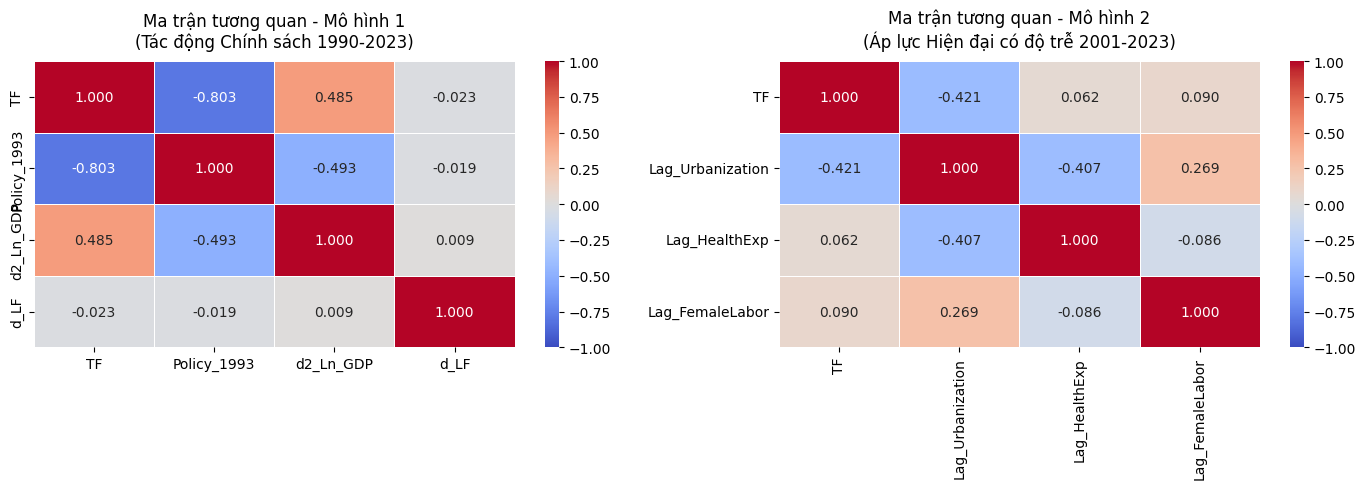

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import kpss
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. NẠP DỮ LIỆU VÀ IN KẾT QUẢ KPSS (P-VALUE)
# ==========================================
df = pd.read_excel("data.xlsx")

# Xử lý các biến số
df['LF'] = df['LF'].bfill()
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)
df['d2_Ln_GDP'] = np.log(df['GDP']).diff().diff()
df['d_LF'] = df['LF'].diff()

df['d_UP'] = df['UP'].diff()
df['d_Hexp'] = df['Hexp'].diff()

# Lấy KPSS cho bạn thấy rõ P-value
d_UP_clean = df['d_UP'].dropna()
kpss_stat, kpss_p_value, lags, crit = kpss(d_UP_clean, regression='c')
print(f"-> Kiểm định KPSS cho d_UP (Tốc độ Đô thị hóa):")
print(f"   P-value = {kpss_p_value:.4f}")
if kpss_p_value > 0.05:
    print("   Kết luận: CHUỖI ĐÃ DỪNG (Stationary) theo KPSS.\n")

# Tạo các biến độ trễ (Lag 1) cho Mô hình 2
df['d_UP_lag1'] = df['d_UP'].shift(1)
df['d_Hexp_lag1'] = df['d_Hexp'].shift(1)
df['d_LF_lag1'] = df['d_LF'].shift(1)

# ==========================================
# 2. CHUẨN BỊ DỮ LIỆU CHO 2 MÔ HÌNH
# ==========================================
# Data Mô hình 1 (1990 - 2023)
df_m1 = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].dropna(subset=['TF', 'Policy_1993', 'd2_Ln_GDP', 'd_LF'])
corr_m1 = df_m1[['TF', 'Policy_1993', 'd2_Ln_GDP', 'd_LF']].corr()

# Data Mô hình 2 (2001 - 2023)
df_m2 = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)].dropna(subset=['TF', 'd_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1'])
# Đổi tên cột cho đẹp trên biểu đồ
df_m2_plot = df_m2[['TF', 'd_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1']].rename(columns={
    'd_UP_lag1': 'Lag_Urbanization',
    'd_Hexp_lag1': 'Lag_HealthExp',
    'd_LF_lag1': 'Lag_FemaleLabor'
})
corr_m2 = df_m2_plot.corr()

# ==========================================
# 3. VẼ BIỂU ĐỒ MA TRẬN TƯƠNG QUAN
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vẽ Ma trận 1
sns.heatmap(corr_m1, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, 
            linewidths=0.5, ax=axes[0], annot_kws={"size": 10})
axes[0].set_title("Ma trận tương quan - Mô hình 1\n(Tác động Chính sách 1990-2023)", fontsize=12, pad=10)

# Vẽ Ma trận 2
sns.heatmap(corr_m2, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, 
            linewidths=0.5, ax=axes[1], annot_kws={"size": 10})
axes[1].set_title("Ma trận tương quan - Mô hình 2\n(Áp lực Hiện đại có độ trễ 2001-2023)", fontsize=12, pad=10)

plt.tight_layout()
plt.savefig("Correlation_Matrices_Both_Models.png", dpi=300)
plt.show()


KẾT QUẢ HUẤN LUYỆN ARIMAX (CÓ BIẾN CHÍNH SÁCH VÀ ĐÔ THỊ HÓA)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   34
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  47.462
Date:                Fri, 03 Apr 2026   AIC                            -82.925
Time:                        15:46:18   BIC                            -73.766
Sample:                             0   HQIC                           -79.801
                                 - 34                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.2197      0.154      1.426      0.154      -0.082       0.522
Policy_1993     0.0199      0.067      0.297      0.766      -0.11

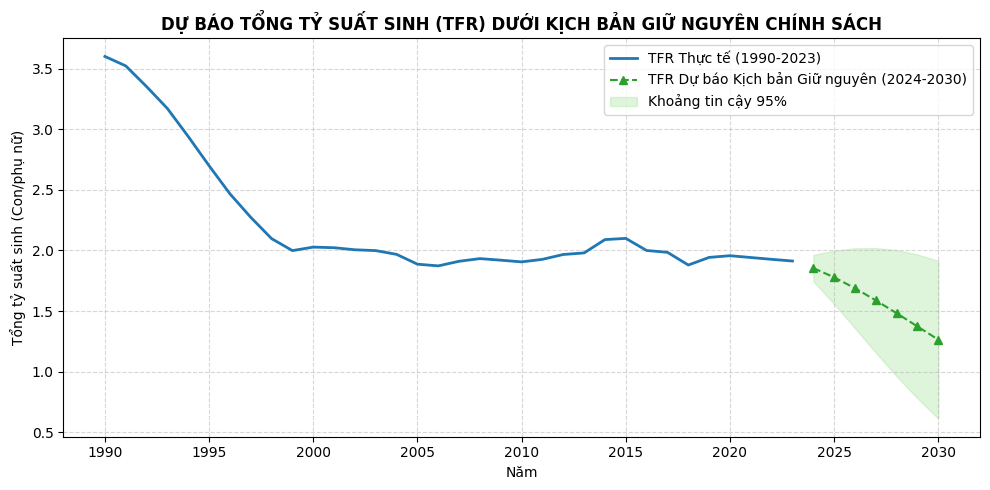


--- BẢNG SỐ LIỆU DỰ BÁO KỊCH BẢN GIỮ NGUYÊN CHÍNH SÁCH ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.855
2025                1                 39.883       1.778
2026                1                 40.759       1.688
2027                1                 41.636       1.588
2028                1                 42.512       1.482
2029                1                 43.389       1.373
2030                1                 44.265       1.264


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore") # Tắt các cảnh báo đỏ cho gọn kết quả

# 1. NẠP VÀ CHUẨN BỊ DỮ LIỆU
df = pd.read_excel("data.xlsx")

# Tạo biến giả Chính sách (1 từ 1993, 0 trước đó)
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Lấy dữ liệu huấn luyện từ 1990 - 2023
train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

# Khai báo Y và các biến X (Ngoại sinh)
y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']] 

# 2. HUẤN LUYỆN MÔ HÌNH ARIMAX
print("\n" + "="*70)
print("KẾT QUẢ HUẤN LUYỆN ARIMAX (CÓ BIẾN CHÍNH SÁCH VÀ ĐÔ THỊ HÓA)")
print("="*70)

# Thuật toán tự dò tìm cấu trúc tốt nhất
model_arimax = auto_arima(y_train, X=X_train, 
                          seasonal=False, stepwise=True, 
                          trace=False, suppress_warnings=True)
print(model_arimax.summary())

# 3. THIẾT LẬP KỊCH BẢN TƯƠNG LAI (2024 - 2030)
future_years = np.arange(2024, 2031)

# *** KỊCH BẢN CHÍNH SÁCH: GIỮ NGUYÊN (1) TRONG TOÀN BỘ GIAI ĐOẠN DỰ BÁO ***
future_policy = [1, 1, 1, 1, 1, 1, 1]

# Kịch bản Đô thị hóa: Giả định tăng trung bình dựa trên quán tính 5 năm cuối
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up)) 
last_up = train_df['UP'].iloc[-1]
future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# Tạo ma trận biến ngoại sinh cho tương lai
X_future = pd.DataFrame({'Policy_1993': future_policy, 'UP': future_up}, index=future_years)

# 4. THỰC HIỆN DỰ BÁO
forecast, conf_int = model_arimax.predict(n_periods=7, X=X_future, return_conf_int=True)

# 5. VẼ BIỂU ĐỒ DỰ BÁO TRỰC QUAN
plt.figure(figsize=(10, 5))

# TFR Thực tế
plt.plot(train_df['Year'], train_df['TF'], label='TFR Thực tế (1990-2023)', color='#1f77b4', linewidth=2)

# TFR Dự báo (Màu xanh lá để phân biệt với kịch bản trước)
plt.plot(future_years, forecast, label='TFR Dự báo Kịch bản Giữ nguyên (2024-2030)', color='#2ca02c', linestyle='--', marker='^')

# Vẽ vùng tin cậy 95%
plt.fill_between(future_years, conf_int[:, 0], conf_int[:, 1], color='#98df8a', alpha=0.3, label='Khoảng tin cậy 95%')

# Tùy chỉnh biểu đồ
plt.title('DỰ BÁO TỔNG TỶ SUẤT SINH (TFR) DƯỚI KỊCH BẢN GIỮ NGUYÊN CHÍNH SÁCH', fontsize=12, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Tổng tỷ suất sinh (Con/phụ nữ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Lưu ảnh để dán vào bài
plt.savefig("Forecast_Keep_Policy.png", dpi=300)
plt.show()

# 6. IN SỐ LIỆU ĐỂ BẠN LẤY BẢNG
forecast_df = pd.DataFrame({'Năm': future_years, 'Kịch bản Policy': future_policy, 'Dự báo Đô thị hóa (%)': future_up, 'TFR Dự báo': forecast})
print("\n--- BẢNG SỐ LIỆU DỰ BÁO KỊCH BẢN GIỮ NGUYÊN CHÍNH SÁCH ---")
print(forecast_df.round(3).to_string(index=False))

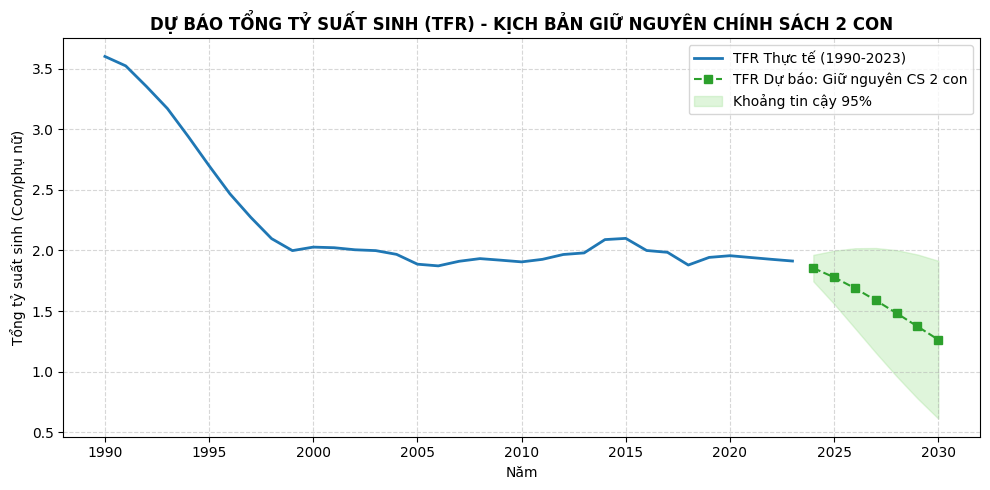


BẢNG SỐ LIỆU DỰ BÁO: KỊCH BẢN GIỮ NGUYÊN
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.855
2025                1                 39.883       1.778
2026                1                 40.759       1.688
2027                1                 41.636       1.588
2028                1                 42.512       1.482
2029                1                 43.389       1.373
2030                1                 44.265       1.264


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore") 

# 1. NẠP VÀ CHUẨN BỊ DỮ LIỆU
df = pd.read_excel("data.xlsx")

# Tạo biến giả Chính sách (1 từ 1993, 0 trước đó)
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

# Lấy dữ liệu huấn luyện từ 1990 - 2023
train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

# Khai báo Y và các biến X (Ngoại sinh)
y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']] 

# 2. HUẤN LUYỆN MÔ HÌNH ARIMAX
model_arimax = auto_arima(y_train, X=X_train, 
                          seasonal=False, stepwise=True, 
                          trace=False, suppress_warnings=True)

# 3. THIẾT LẬP KỊCH BẢN TƯƠNG LAI: GIỮ NGUYÊN CHÍNH SÁCH (2024 - 2030)
future_years = np.arange(2024, 2031)

# KHÁC BIỆT TẠI ĐÂY: Chính sách luôn bằng 1 (Duy trì kịch bản hiện tại)
future_policy = [1] * len(future_years)

# Kịch bản Đô thị hóa: Giữ nguyên cách tính theo quán tính cũ
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up)) 
last_up = train_df['UP'].iloc[-1]
future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# Tạo ma trận biến ngoại sinh cho kịch bản Giữ nguyên
X_future_maintain = pd.DataFrame({'Policy_1993': future_policy, 'UP': future_up}, index=future_years)

# 4. THỰC HIỆN DỰ BÁO
forecast, conf_int = model_arimax.predict(n_periods=7, X=X_future_maintain, return_conf_int=True)

# 5. VẼ BIỂU ĐỒ DỰ BÁO
plt.figure(figsize=(10, 5))

# TFR Thực tế
plt.plot(train_df['Year'], train_df['TF'], label='TFR Thực tế (1990-2023)', color='#1f77b4', linewidth=2)

# TFR Dự báo (Kịch bản giữ nguyên)
plt.plot(future_years, forecast, label='TFR Dự báo: Giữ nguyên CS 2 con', color='#2ca02c', linestyle='--', marker='s')

# Vẽ vùng tin cậy 95%
plt.fill_between(future_years, conf_int[:, 0], conf_int[:, 1], color='#98df8a', alpha=0.3, label='Khoảng tin cậy 95%')

plt.title('DỰ BÁO TỔNG TỶ SUẤT SINH (TFR) - KỊCH BẢN GIỮ NGUYÊN CHÍNH SÁCH 2 CON', fontsize=12, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Tổng tỷ suất sinh (Con/phụ nữ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 6. IN SỐ LIỆU
forecast_df = pd.DataFrame({
    'Năm': future_years, 
    'Kịch bản Policy': future_policy, 
    'Dự báo Đô thị hóa (%)': future_up, 
    'TFR Dự báo': forecast
})
print("\n" + "="*40)
print("BẢNG SỐ LIỆU DỰ BÁO: KỊCH BẢN GIỮ NGUYÊN")
print("="*40)
print(forecast_df.round(3).to_string(index=False))

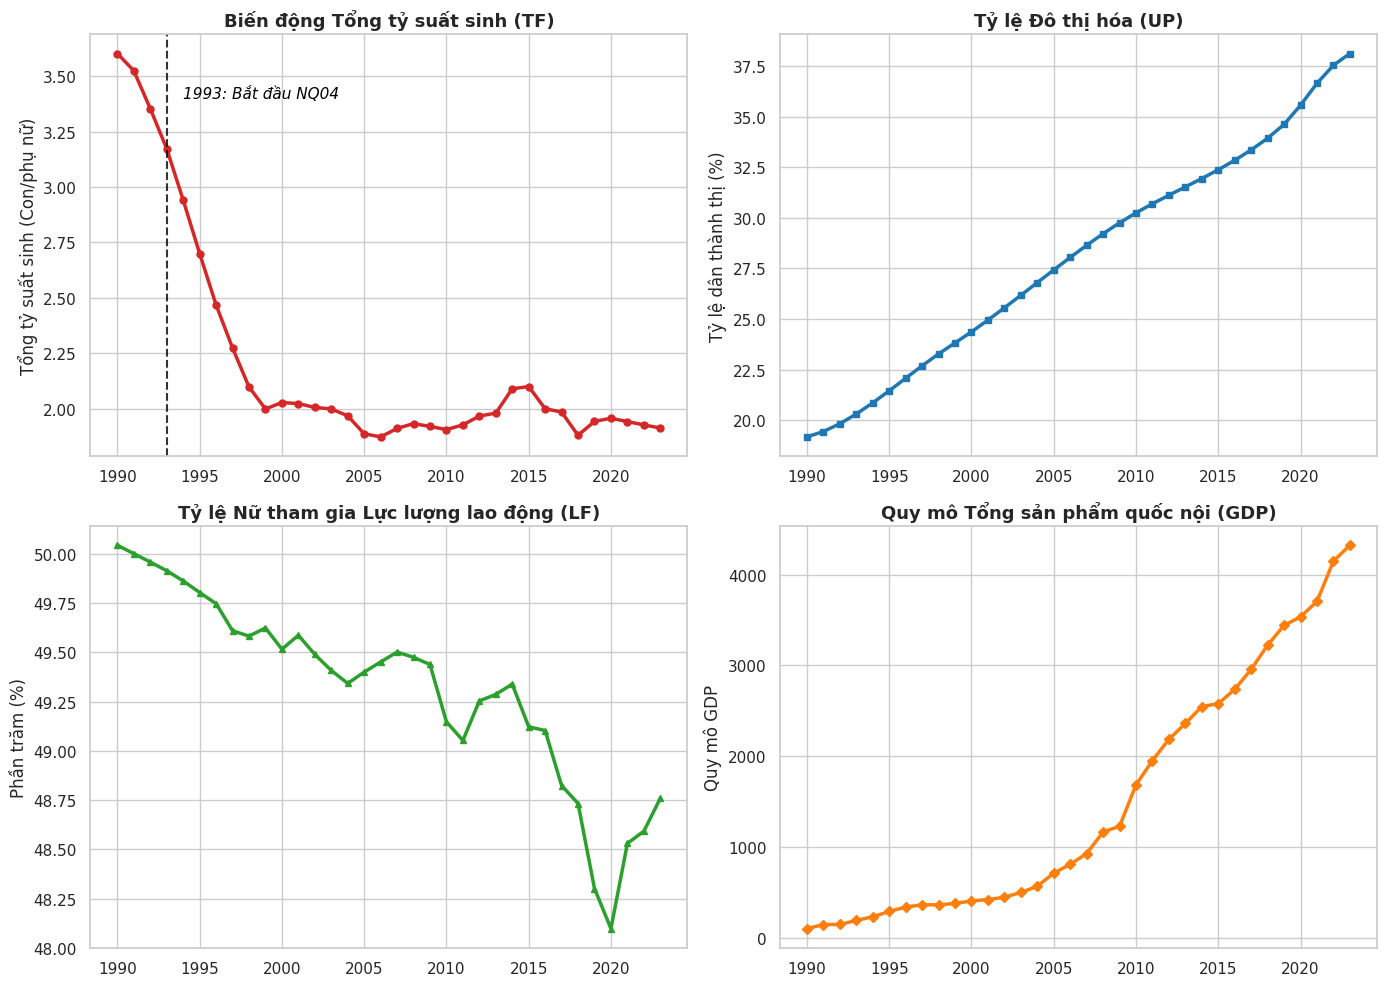

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. NẠP DỮ LIỆU
df = pd.read_excel("data.xlsx")
df_plot = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
# Khắc phục dữ liệu trống cho LF nếu có
df_plot['LF'] = df_plot['LF'].bfill()

# 2. THIẾT LẬP STYLE CHO BIỂU ĐỒ (Chuẩn bài báo khoa học)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Tạo một khung hình lớn chứa 4 biểu đồ con (2 hàng, 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Biểu đồ 1: Tỷ suất sinh (TF) ---
axes[0, 0].plot(df_plot['Year'], df_plot['TF'], color='#d62728', linewidth=2.5, marker='o', markersize=5)
axes[0, 0].set_title('Biến động Tổng tỷ suất sinh (TF)', fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Tổng tỷ suất sinh (Con/phụ nữ)')
# Thêm đường kẻ dọc đánh dấu năm ra Nghị quyết 04 (1993)
axes[0, 0].axvline(x=1993, color='black', linestyle='--', alpha=0.8, linewidth=1.5)
axes[0, 0].text(1994, max(df_plot['TF'])-0.2, '1993: Bắt đầu NQ04', fontsize=11, style='italic', color='black')

# --- Biểu đồ 2: Đô thị hóa (UP) ---
axes[0, 1].plot(df_plot['Year'], df_plot['UP'], color='#1f77b4', linewidth=2.5, marker='s', markersize=5)
axes[0, 1].set_title('Tỷ lệ Đô thị hóa (UP)', fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('Tỷ lệ dân thành thị (%)')

# --- Biểu đồ 3: Lao động nữ (LF) ---
axes[1, 0].plot(df_plot['Year'], df_plot['LF'], color='#2ca02c', linewidth=2.5, marker='^', markersize=5)
axes[1, 0].set_title('Tỷ lệ Nữ tham gia Lực lượng lao động (LF)', fontweight='bold', fontsize=13)
axes[1, 0].set_ylabel('Phần trăm (%)')

# --- Biểu đồ 4: Tăng trưởng GDP ---
axes[1, 1].plot(df_plot['Year'], df_plot['GDP'], color='#ff7f0e', linewidth=2.5, marker='D', markersize=5)
axes[1, 1].set_title('Quy mô Tổng sản phẩm quốc nội (GDP)', fontweight='bold', fontsize=13)
axes[1, 1].set_ylabel('Quy mô GDP')

# Căn chỉnh và lưu ảnh
plt.tight_layout()
plt.savefig("Data_Description_Trends.png", dpi=300)
plt.show()

In [1]:
import pandas as pd

# 1. NẠP DỮ LIỆU GIAI ĐOẠN 1990 - 2023
df = pd.read_excel("data.xlsx")
df_pre = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()

# Khắc phục biến LF nếu có trống
df_pre['LF'] = df_pre['LF'].bfill()

# 2. TẠO BẢNG THỐNG KÊ MÔ TẢ CHUẨN ACADEMIC
# Chọn các biến đưa vào bảng
variables = ['TF', 'UP', 'LF', 'GDP']
df_stats = df_pre[variables]

# Dùng hàm describe() lấy thông số, đảo dòng thành cột (.T) cho dễ nhìn
desc_table = df_stats.describe().T[['count', 'mean', 'std', 'min', 'max']]

# Đổi tên cột sang tiếng Việt cho chuẩn Khóa luận
desc_table.columns = ['Số quan sát (N)', 'Trung bình (Mean)', 'Độ lệch chuẩn (Std)', 'Nhỏ nhất (Min)', 'Lớn nhất (Max)']

# Làm tròn 3 chữ số thập phân cho đẹp
desc_table = desc_table.round(3)

# 3. IN KẾT QUẢ VÀ XUẤT FILE EXCEL
print("\n" + "="*80)
print("BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (1990 - 2023)")
print("="*80)
print(desc_table)

# Xuất ra file Excel để bạn copy thẳng vào Word
desc_table.to_excel("Bang_Thong_Ke_Mo_Ta.xlsx")
print("\n-> Đã xuất thành công file 'Bang_Thong_Ke_Mo_Ta.xlsx' vào cùng thư mục với code!")
print("-> Bạn hãy mở file này lên, copy bảng và dán vào ngay dưới Bảng 4.1 nhé.")


BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (1990 - 2023)
     Số quan sát (N)  Trung bình (Mean)  Độ lệch chuẩn (Std)  Nhỏ nhất (Min)  \
TF              34.0              2.212                0.504           1.873   
UP              34.0             28.073                5.612          19.174   
LF              34.0             49.321                0.484          48.097   
GDP             34.0           1501.812             1356.101          98.798   

     Lớn nhất (Max)  
TF            3.602  
UP           38.130  
LF           50.045  
GDP        4323.350  

-> Đã xuất thành công file 'Bang_Thong_Ke_Mo_Ta.xlsx' vào cùng thư mục với code!
-> Bạn hãy mở file này lên, copy bảng và dán vào ngay dưới Bảng 4.1 nhé.


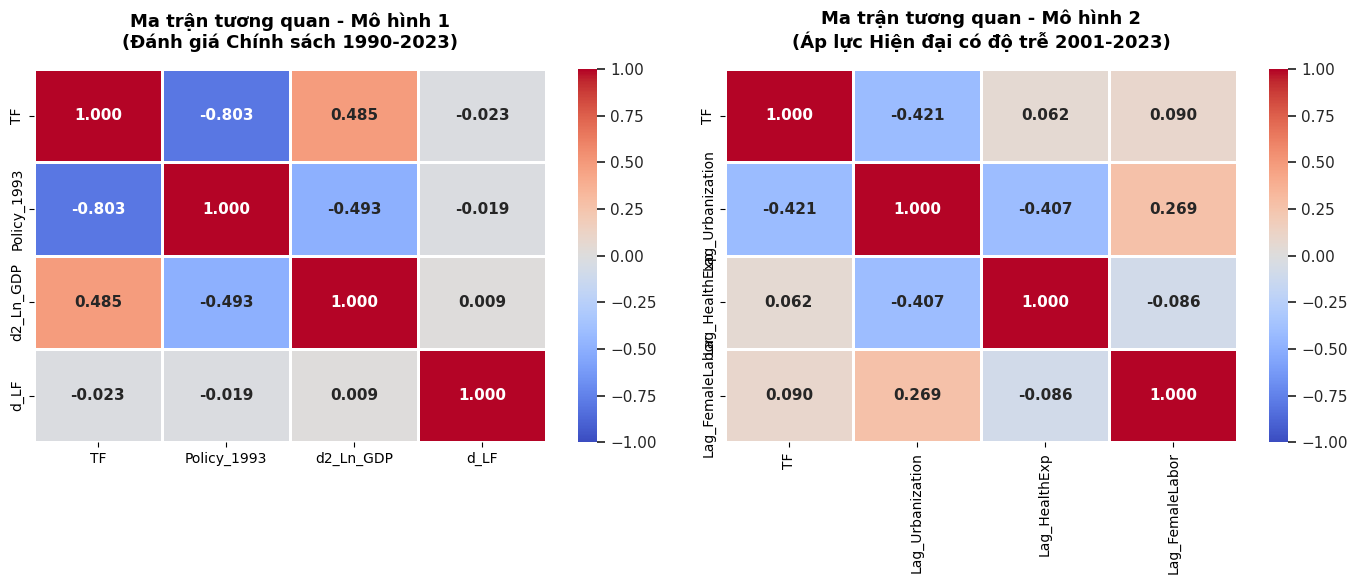

Đã xuất và lưu thành công biểu đồ 'Ma_Tran_Tuong_Quan_2_Mo_Hinh.png'!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. NẠP VÀ XỬ LÝ DỮ LIỆU
# ==========================================
df = pd.read_excel("data.xlsx")
df['LF'] = df['LF'].bfill()

# Tạo biến cho Mô hình 1
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)
df['Ln_GDP'] = np.log(df['GDP'])
df['d2_Ln_GDP'] = df['Ln_GDP'].diff().diff()
df['d_LF'] = df['LF'].diff()

# Tạo biến cho Mô hình 2
df['d_UP'] = df['UP'].diff()
df['d_Hexp'] = df['Hexp'].diff()

# Tạo biến độ trễ 1 năm (Lag 1)
df['d_UP_lag1'] = df['d_UP'].shift(1)
df['d_Hexp_lag1'] = df['d_Hexp'].shift(1)
df['d_LF_lag1'] = df['d_LF'].shift(1)

# ==========================================
# 2. TÁCH DỮ LIỆU ĐỂ TÍNH TƯƠNG QUAN
# ==========================================
# Dữ liệu Mô hình 1 (1990 - 2023)
df_m1 = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].dropna(subset=['TF', 'Policy_1993', 'd2_Ln_GDP', 'd_LF'])
corr_m1 = df_m1[['TF', 'Policy_1993', 'd2_Ln_GDP', 'd_LF']].corr()

# Dữ liệu Mô hình 2 (2001 - 2023)
df_m2 = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)].dropna(subset=['TF', 'd_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1'])

# Đổi tên cột cho biểu đồ dễ đọc, mang tính quốc tế
df_m2_renamed = df_m2[['TF', 'd_UP_lag1', 'd_Hexp_lag1', 'd_LF_lag1']].rename(columns={
    'd_UP_lag1': 'Lag_Urbanization',
    'd_Hexp_lag1': 'Lag_HealthExp',
    'd_LF_lag1': 'Lag_FemaleLabor'
})
corr_m2 = df_m2_renamed.corr()

# ==========================================
# 3. VẼ MA TRẬN TƯƠNG QUAN KÉP
# ==========================================
# Tạo khung hình dài để chứa 2 biểu đồ cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="white")

# Vẽ Heatmap cho Mô hình 1
sns.heatmap(corr_m1, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1,
            linewidths=1, linecolor='white', ax=axes[0], 
            annot_kws={"size": 11, "weight": "bold"})
axes[0].set_title("Ma trận tương quan - Mô hình 1\n(Đánh giá Chính sách 1990-2023)", 
                  fontsize=13, fontweight='bold', pad=15)

# Vẽ Heatmap cho Mô hình 2
sns.heatmap(corr_m2, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1,
            linewidths=1, linecolor='white', ax=axes[1], 
            annot_kws={"size": 11, "weight": "bold"})
axes[1].set_title("Ma trận tương quan - Mô hình 2\n(Áp lực Hiện đại có độ trễ 2001-2023)", 
                  fontsize=13, fontweight='bold', pad=15)

# Căn chỉnh và lưu ảnh
plt.tight_layout()
plt.savefig("Ma_Tran_Tuong_Quan_2_Mo_Hinh.png", dpi=300)
plt.show()

print("Đã xuất và lưu thành công biểu đồ 'Ma_Tran_Tuong_Quan_2_Mo_Hinh.png'!")

In [1]:
import pandas as pd
import numpy as np

# ==========================================
# 1. NẠP VÀ XỬ LÝ DỮ LIỆU
# ==========================================
df = pd.read_excel("data.xlsx")
# Giới hạn giai đoạn nghiên cứu 1990 - 2023
df_pre = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()

# Khắc phục dữ liệu trống (nếu có) bằng phương pháp backfill
df_pre['LF'] = df_pre['LF'].bfill()
if 'Hexp' in df_pre.columns:
    df_pre['Hexp'] = df_pre['Hexp'].bfill()

# ==========================================
# 2. TẠO TOÀN BỘ CÁC BIẾN SỐ ĐÃ SỬ DỤNG
# ==========================================
# Biến chính sách
df_pre['Policy_1993'] = np.where(df_pre['Year'] >= 1993, 1, 0)

# Nhóm biến Kinh tế (Logarit và Sai phân)
df_pre['Ln_GDP'] = np.log(df_pre['GDP'])
df_pre['d_Ln_GDP'] = df_pre['Ln_GDP'].diff()
df_pre['d2_Ln_GDP'] = df_pre['d_Ln_GDP'].diff()

# Nhóm biến Sai phân bậc 1 (Tốc độ thay đổi)
df_pre['d_UP'] = df_pre['UP'].diff()
df_pre['d_LF'] = df_pre['LF'].diff()
if 'Hexp' in df_pre.columns:
    df_pre['d_Hexp'] = df_pre['Hexp'].diff()

# ==========================================
# 3. CHỌN LỌC VÀ LẬP BẢNG THỐNG KÊ
# ==========================================
# Danh sách các biến muốn đưa vào bảng
variables_to_describe = [
    'TF', 'Policy_1993', 'UP', 'LF', 'GDP', 'Hexp', 
    'Ln_GDP', 'd2_Ln_GDP', 'd_UP', 'd_LF', 'd_Hexp'
]

# Lọc chỉ lấy những cột thực sự tồn tại trong file dữ liệu
existing_vars = [var for var in variables_to_describe if var in df_pre.columns]
df_stats = df_pre[existing_vars]

# Tính toán các chỉ số thống kê và chuyển vị (T)
desc_table = df_stats.describe().T[['count', 'mean', 'std', 'min', 'max']]

# Đổi tên cột chuẩn học thuật
desc_table.columns = ['Số quan sát (N)', 'Trung bình (Mean)', 'Độ lệch chuẩn (Std)', 'Nhỏ nhất (Min)', 'Lớn nhất (Max)']

# Đổi tên hàng (Tên biến) cho hội đồng dễ hiểu
rename_dict = {
    'TF': 'TF (Tổng tỷ suất sinh)',
    'Policy_1993': 'Policy (Biến giả chính sách)',
    'UP': 'UP (Tỷ lệ Đô thị hóa gốc, %)',
    'LF': 'LF (Tỷ lệ Lao động nữ gốc, %)',
    'GDP': 'GDP (Quy mô kinh tế gốc)',
    'Hexp': 'Hexp (Chi tiêu y tế gốc)',
    'Ln_GDP': 'Ln_GDP (Logarit tự nhiên của GDP)',
    'd2_Ln_GDP': 'd2_Ln_GDP (Gia tốc tăng trưởng GDP)',
    'd_UP': 'd_UP (Tốc độ Đô thị hóa)',
    'd_LF': 'd_LF (Tốc độ thay đổi LĐ nữ)',
    'd_Hexp': 'd_Hexp (Tốc độ tăng chi tiêu y tế)'
}
desc_table = desc_table.rename(index=rename_dict)

# Làm tròn 3 chữ số thập phân
desc_table = desc_table.round(3)

# ==========================================
# 4. IN KẾT QUẢ VÀ XUẤT FILE EXCEL
# ==========================================
print("\n" + "="*90)
print("BẢNG THỐNG KÊ MÔ TẢ TỔNG HỢP TOÀN BỘ BIẾN SỐ (1990 - 2023)")
print("="*90)
print(desc_table)

# Xuất file Excel
file_name = "Thong_Ke_Mo_Ta_Toan_Dien.xlsx"
desc_table.to_excel(file_name)
print(f"\n-> Đã xuất thành công file '{file_name}'!")
print("-> Bạn hãy mở file này, copy và thay thế bảng thống kê cũ trong khóa luận nhé.")


BẢNG THỐNG KÊ MÔ TẢ TỔNG HỢP TOÀN BỘ BIẾN SỐ (1990 - 2023)
                                     Số quan sát (N)  Trung bình (Mean)  \
TF (Tổng tỷ suất sinh)                          34.0              2.212   
Policy (Biến giả chính sách)                    34.0              0.912   
UP (Tỷ lệ Đô thị hóa gốc, %)                    34.0             28.073   
LF (Tỷ lệ Lao động nữ gốc, %)                   34.0             49.321   
GDP (Quy mô kinh tế gốc)                        34.0           1501.812   
Hexp (Chi tiêu y tế gốc)                        34.0             36.979   
Ln_GDP (Logarit tự nhiên của GDP)               34.0              6.786   
d2_Ln_GDP (Gia tốc tăng trưởng GDP)             32.0             -0.010   
d_UP (Tốc độ Đô thị hóa)                        33.0              0.574   
d_LF (Tốc độ thay đổi LĐ nữ)                    33.0             -0.039   
d_Hexp (Tốc độ tăng chi tiêu y tế)              33.0              0.140   

                                     Độ

In [6]:
future_years = np.arange(2024, 2031)

# Dự báo đô thị hóa
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up))
last_up = train_df['UP'].iloc[-1]

future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

In [7]:
policy_continue = [1, 1, 1, 1, 1, 1, 1]

X_continue = pd.DataFrame({
    'Policy': policy_continue,
    'UP': future_up
})

forecast_continue = model.predict(
    n_periods=7,
    exogenous=X_continue
)

df_continue = pd.DataFrame({
    "Năm": future_years,
    "Kịch bản Policy": policy_continue,
    "Dự báo Đô thị hóa (%)": np.round(future_up, 3),
    "TFR Dự báo": np.round(forecast_continue, 3)
})

print("\n--- KỊCH BẢN 1: TIẾP TỤC CHÍNH SÁCH ---")
print(df_continue.to_string(index=False))


--- KỊCH BẢN 1: TIẾP TỤC CHÍNH SÁCH ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.899
2025                1                 39.883       1.885
2026                1                 40.759       1.871
2027                1                 41.636       1.857
2028                1                 42.512       1.843
2029                1                 43.389       1.829
2030                1                 44.265       1.815


In [8]:
policy_remove = [1, 1, 0, 0, 0, 0, 0]

X_remove = pd.DataFrame({
    'Policy': policy_remove,
    'UP': future_up
})

forecast_remove = model.predict(
    n_periods=7,
    exogenous=X_remove
)

df_remove = pd.DataFrame({
    "Năm": future_years,
    "Kịch bản Policy": policy_remove,
    "Dự báo Đô thị hóa (%)": np.round(future_up, 3),
    "TFR Dự báo": np.round(forecast_remove, 3)
})

print("\n--- KỊCH BẢN 2: BÃI BỎ CHÍNH SÁCH ---")
print(df_remove.to_string(index=False))


--- KỊCH BẢN 2: BÃI BỎ CHÍNH SÁCH ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.899
2025                1                 39.883       1.885
2026                0                 40.759       1.871
2027                0                 41.636       1.857
2028                0                 42.512       1.843
2029                0                 43.389       1.829
2030                0                 44.265       1.815


In [4]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima

# ===== 1. LOAD DATA =====
df = pd.read_excel("data.xlsx")

df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']]

# ===== 2. TRAIN MODEL (CHỈ 1 LẦN) =====
model = auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True
)

# ===== 3. TẠO DỮ LIỆU TƯƠNG LAI =====
future_years = np.arange(2024, 2031)

# Dự báo đô thị hóa
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up))
last_up = train_df['UP'].iloc[-1]

future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

# ===== 4. KỊCH BẢN 1: TIẾP TỤC =====
policy_continue = [1, 1, 1, 1, 1, 1, 1]

X_continue = pd.DataFrame({
    'Policy_1993': policy_continue,
    'UP': future_up
})

forecast_continue = model.predict(
    n_periods=7,
    exogenous=X_continue
)

df_continue = pd.DataFrame({
    "Năm": future_years,
    "Kịch bản Policy": policy_continue,
    "Dự báo Đô thị hóa (%)": np.round(future_up, 3),
    "TFR Dự báo": np.round(forecast_continue, 3)
})

# ===== 5. KỊCH BẢN 2: BÃI BỎ =====
policy_remove = [1, 1, 0, 0, 0, 0, 0]

X_remove = pd.DataFrame({
    'Policy_1993': policy_remove,
    'UP': future_up
})

forecast_remove = model.predict(
    n_periods=7,
    exogenous=X_remove
)

df_remove = pd.DataFrame({
    "Năm": future_years,
    "Kịch bản Policy": policy_remove,
    "Dự báo Đô thị hóa (%)": np.round(future_up, 3),
    "TFR Dự báo": np.round(forecast_remove, 3)
})

# ===== 6. BẢNG SO SÁNH =====
df_compare = pd.DataFrame({
    "Năm": future_years,
    "TFR - Tiếp tục": np.round(forecast_continue, 3),
    "TFR - Bãi bỏ": np.round(forecast_remove, 3),
    "Chênh lệch (Remove - Continue)": np.round(forecast_remove - forecast_continue, 3)
})

# ===== 7. IN RA KẾT QUẢ =====
print("\n--- KỊCH BẢN 1: TIẾP TỤC CHÍNH SÁCH ---")
print(df_continue.to_string(index=False))

print("\n--- KỊCH BẢN 2: BÃI BỎ CHÍNH SÁCH ---")
print(df_remove.to_string(index=False))

print("\n--- BẢNG SO SÁNH 2 KỊCH BẢN ---")
print(df_compare.to_string(index=False))

# ===== 8. LƯU FILE (dùng cho Word/Excel) =====
df_continue.to_csv("forecast_continue.csv", index=False)
df_remove.to_csv("forecast_remove.csv", index=False)
df_compare.to_csv("forecast_compare.csv", index=False)


--- KỊCH BẢN 1: TIẾP TỤC CHÍNH SÁCH ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.899
2025                1                 39.883       1.885
2026                1                 40.759       1.871
2027                1                 41.636       1.857
2028                1                 42.512       1.843
2029                1                 43.389       1.829
2030                1                 44.265       1.815

--- KỊCH BẢN 2: BÃI BỎ CHÍNH SÁCH ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       1.899
2025                1                 39.883       1.885
2026                0                 40.759       1.871
2027                0                 41.636       1.857
2028                0                 42.512       1.843
2029                0                 43.389       1.829
2030                0                 44.265       1.815

--- BẢN

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pmdarima import auto_arima

# Load data
df = pd.read_excel("data.xlsx")

# Tạo biến policy có variation (QUAN TRỌNG)
df['Policy'] = np.where(df['Year'] >= 1993, 1, 0)

# Chọn data
df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].copy()

# Drop NA
df = df.dropna(subset=['TF', 'UP', 'Policy'])

In [4]:
X = df[['Policy', 'UP']]
X = sm.add_constant(X)

y = df['TF']

model_ols = sm.OLS(y, X).fit()

print("\n===== KẾT QUẢ OLS =====")
print(model_ols.summary())

# Lấy hệ số policy
beta_policy = model_ols.params['Policy']
print("\nHệ số Policy =", beta_policy)


===== KẾT QUẢ OLS =====
                            OLS Regression Results                            
Dep. Variable:                     TF   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     59.13
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.63e-11
Time:                        14:20:18   Log-Likelihood:                 2.3064
No. Observations:                  34   AIC:                             1.387
Df Residuals:                      31   BIC:                             5.966
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2581      

In [5]:
from pmdarima import auto_arima

model_arima = auto_arima(
    df['TF'],
    d=1,              # 🔥 ÉP sai phân bậc 1
    max_d=1,          # 🔥 KHÔNG cho lên bậc 2
    seasonal=False,
    stepwise=True,
    suppress_warnings=True
)
print("\n===== ARIMA MODEL =====")
print(model_arima.summary())

# Forecast 2024–2030
future_years = np.arange(2024, 2031)
baseline_forecast = model_arima.predict(n_periods=7)


===== ARIMA MODEL =====
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   34
Model:               SARIMAX(1, 1, 0)   Log Likelihood                  45.485
Date:                Mon, 20 Apr 2026   AIC                            -86.970
Time:                        14:20:21   BIC                            -83.977
Sample:                             0   HQIC                           -85.963
                                 - 34                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8048      0.109      7.405      0.000       0.592       1.018
sigma2         0.0036      0.001      3.733      0.000       0.002       0.005
Ljung-Box (L1) (Q):        

In [6]:
last_5_up = df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up))
last_up = df['UP'].iloc[-1]

future_up = [last_up + avg_up_growth * i for i in range(1, 8)]

In [7]:
# Scenario 1: tiếp tục chính sách
policy_continue = [1, 1, 1, 1, 1, 1, 1]

# Scenario 2: bãi bỏ từ 2026
policy_remove = [1, 1, 0, 0, 0, 0, 0]

In [8]:
forecast_continue = baseline_forecast + beta_policy * np.array(policy_continue)
forecast_remove = baseline_forecast + beta_policy * np.array(policy_remove)

In [9]:
df_continue = pd.DataFrame({
    "Năm": future_years,
    "Kịch bản Policy": policy_continue,
    "Dự báo Đô thị hóa (%)": np.round(future_up, 3),
    "TFR Dự báo": np.round(forecast_continue, 3)
})

print("\n--- KỊCH BẢN 1: TIẾP TỤC ---")
print(df_continue.to_string(index=False))


--- KỊCH BẢN 1: TIẾP TỤC ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       0.867
2025                1                 39.883       0.858
2026                1                 40.759       0.850
2027                1                 41.636       0.844
2028                1                 42.512       0.840
2029                1                 43.389       0.836
2030                1                 44.265       0.833


In [10]:
df_remove = pd.DataFrame({
    "Năm": future_years,
    "Kịch bản Policy": policy_remove,
    "Dự báo Đô thị hóa (%)": np.round(future_up, 3),
    "TFR Dự báo": np.round(forecast_remove, 3)
})

print("\n--- KỊCH BẢN 2: BÃI BỎ ---")
print(df_remove.to_string(index=False))


--- KỊCH BẢN 2: BÃI BỎ ---
 Năm  Kịch bản Policy  Dự báo Đô thị hóa (%)  TFR Dự báo
2024                1                 39.006       0.867
2025                1                 39.883       0.858
2026                0                 40.759       1.885
2027                0                 41.636       1.879
2028                0                 42.512       1.875
2029                0                 43.389       1.871
2030                0                 44.265       1.868


In [11]:
df_compare = pd.DataFrame({
    "Năm": future_years,
    "TFR - Tiếp tục": np.round(forecast_continue, 3),
    "TFR - Bãi bỏ": np.round(forecast_remove, 3),
    "Chênh lệch (Remove - Continue)": np.round(forecast_remove - forecast_continue, 3)
})

print("\n--- SO SÁNH 2 KỊCH BẢN ---")
print(df_compare.to_string(index=False))


--- SO SÁNH 2 KỊCH BẢN ---
 Năm  TFR - Tiếp tục  TFR - Bãi bỏ  Chênh lệch (Remove - Continue)
2024           0.867         0.867                           0.000
2025           0.858         0.858                           0.000
2026           0.850         1.885                           1.035
2027           0.844         1.879                           1.035
2028           0.840         1.875                           1.035
2029           0.836         1.871                           1.035
2030           0.833         1.868                           1.035


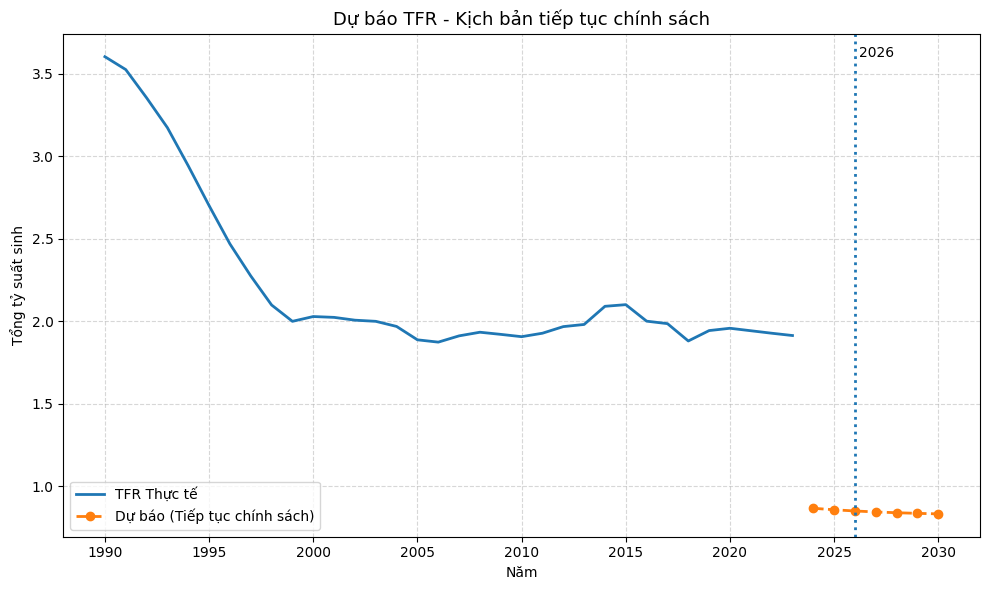

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Dữ liệu thực tế
plt.plot(df['Year'], df['TF'], label='TFR Thực tế', linewidth=2)

# Dự báo
plt.plot(future_years, forecast_continue, 
         linestyle='--', marker='o', linewidth=2, 
         label='Dự báo (Tiếp tục chính sách)')

# Đánh dấu năm 2026
plt.axvline(x=2026, linestyle=':', linewidth=2)
plt.text(2026.2, max(df['TF']), '2026', fontsize=10)

plt.title('Dự báo TFR - Kịch bản tiếp tục chính sách', fontsize=13)
plt.xlabel('Năm')
plt.ylabel('Tổng tỷ suất sinh')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("scenario_continue.png", dpi=300)
plt.show()

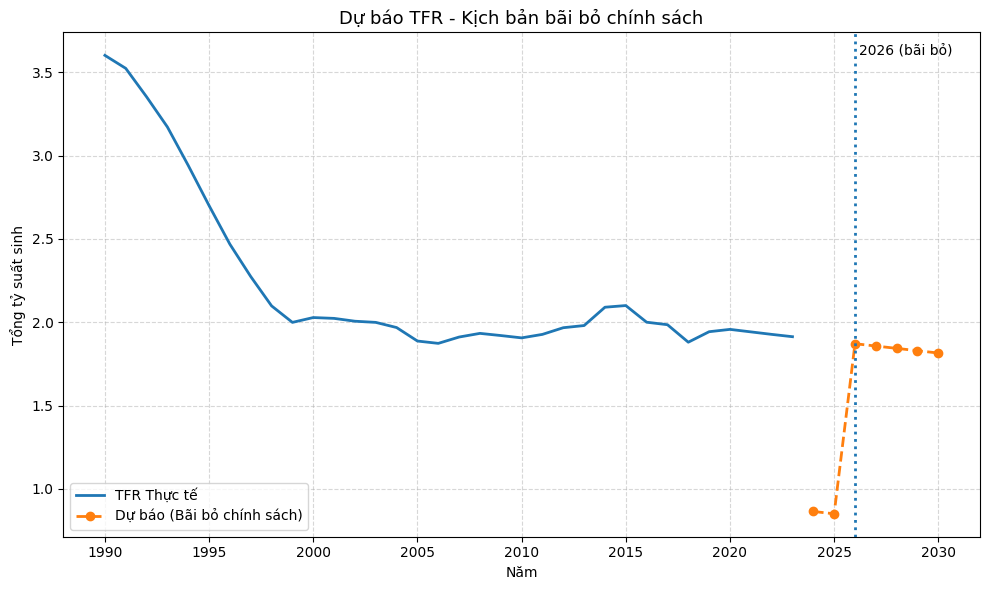

In [20]:
plt.figure(figsize=(10,6))

# Dữ liệu thực tế
plt.plot(df['Year'], df['TF'], label='TFR Thực tế', linewidth=2)

# Dự báo
plt.plot(future_years, forecast_remove, 
         linestyle='--', marker='o', linewidth=2, 
         label='Dự báo (Bãi bỏ chính sách)')

# Đánh dấu năm 2026
plt.axvline(x=2026, linestyle=':', linewidth=2)
plt.text(2026.2, max(df['TF']), '2026 (bãi bỏ)', fontsize=10)

plt.title('Dự báo TFR - Kịch bản bãi bỏ chính sách', fontsize=13)
plt.xlabel('Năm')
plt.ylabel('Tổng tỷ suất sinh')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("scenario_remove.png", dpi=300)
plt.show()


--- BẢNG SO SÁNH 2 KỊCH BẢN CHÍNH XÁC ---
 Năm  TFR (Giữ nguyên)  TFR (Bãi bỏ từ 2026)  Chênh lệch
2024             1.855                 1.855        0.00
2025             1.778                 1.778        0.00
2026             1.688                 1.668       -0.02
2027             1.588                 1.568       -0.02
2028             1.482                 1.462       -0.02
2029             1.373                 1.353       -0.02
2030             1.264                 1.244       -0.02


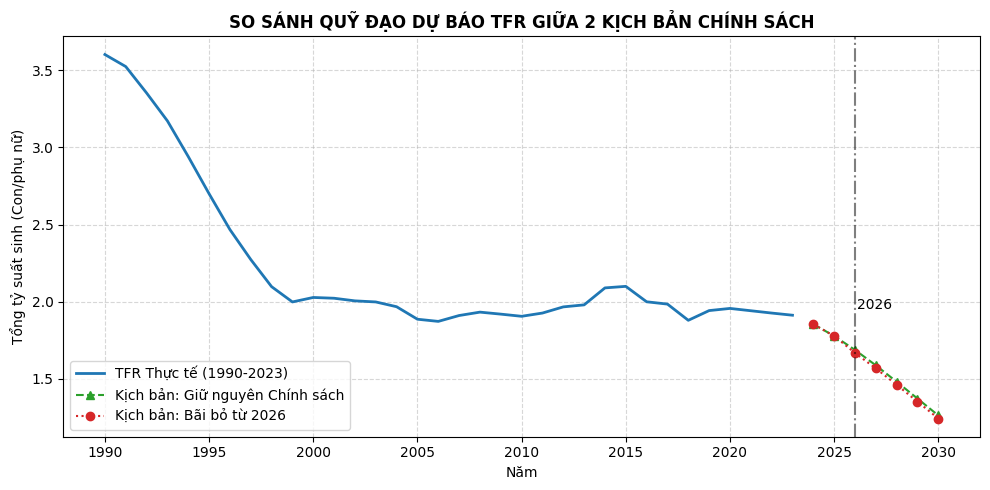

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

# 1. NẠP DỮ LIỆU VÀ HUẤN LUYỆN MÔ HÌNH
df = pd.read_excel("data.xlsx")
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].dropna(subset=['TF', 'Policy_1993', 'UP'])
y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']]

model_arimax = auto_arima(y_train, X=X_train, seasonal=False, stepwise=True, trace=False, suppress_warnings=True)

# 2. XÂY DỰNG CÁC BIẾN NGOẠI SINH TƯƠNG LAI
future_years = np.arange(2024, 2031)

# Giả định Đô thị hóa
last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up))
future_up = [train_df['UP'].iloc[-1] + avg_up_growth * i for i in range(1, 8)]

# Ma trận 1: KỊCH BẢN GIỮ NGUYÊN (1) toàn thời gian
X_keep = pd.DataFrame({'Policy_1993': [1, 1, 1, 1, 1, 1, 1], 'UP': future_up}, index=future_years)

# Ma trận 2: KỊCH BẢN BÃI BỎ TỪ 2026 (0 từ năm 2026 trở đi)
X_remove = pd.DataFrame({'Policy_1993': [1, 1, 0, 0, 0, 0, 0], 'UP': future_up}, index=future_years)

# 3. THỰC HIỆN DỰ BÁO ĐỘC LẬP
# Lấy kết quả TFR dự báo (không lấy khoảng tin cậy để bảng cho gọn)
pred_keep = model_arimax.predict(n_periods=7, X=X_keep)
pred_remove = model_arimax.predict(n_periods=7, X=X_remove)

# 4. TẠO BẢNG SO SÁNH CHUẨN XÁC
compare_df = pd.DataFrame({
    'Năm': future_years,
    'TFR (Giữ nguyên)': pred_keep.values,
    'TFR (Bãi bỏ từ 2026)': pred_remove.values
})
compare_df['Chênh lệch'] = compare_df['TFR (Bãi bỏ từ 2026)'] - compare_df['TFR (Giữ nguyên)']

print("\n--- BẢNG SO SÁNH 2 KỊCH BẢN CHÍNH XÁC ---")
print(compare_df.round(3).to_string(index=False))

# 5. VẼ BIỂU ĐỒ SO SÁNH
plt.figure(figsize=(10, 5))
plt.plot(train_df['Year'], train_df['TF'], label='TFR Thực tế (1990-2023)', color='#1f77b4', linewidth=2)
plt.plot(future_years, pred_keep, label='Kịch bản: Giữ nguyên Chính sách', color='#2ca02c', linestyle='--', marker='^')
plt.plot(future_years, pred_remove, label='Kịch bản: Bãi bỏ từ 2026', color='#d62728', linestyle=':', marker='o')

plt.axvline(x=2026, color='black', linestyle='-.', alpha=0.5)
plt.text(2026.1, max(pred_keep)+0.1, '2026', fontsize=10)

plt.title('SO SÁNH QUỸ ĐẠO DỰ BÁO TFR GIỮA 2 KỊCH BẢN CHÍNH SÁCH', fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Tổng tỷ suất sinh (Con/phụ nữ)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("Compare_Scenarios.png", dpi=300)
plt.show()

In [18]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
import warnings

# Tắt các cảnh báo để kết quả in ra màn hình được gọn gàng
warnings.filterwarnings("ignore") 

# =====================================================================
# PHẦN 1: NẠP DỮ LIỆU VÀ CHUẨN BỊ MÔ HÌNH (GIAI ĐOẠN 1990 - 2023)
# =====================================================================
df = pd.read_excel("data.xlsx")
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].dropna(subset=['TF', 'Policy_1993', 'UP'])
y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']]

# =====================================================================
# PHẦN 2: HUẤN LUYỆN THUẬT TOÁN ARIMAX
# =====================================================================
print("\nĐang huấn luyện mô hình ARIMAX...")
model_arimax = auto_arima(y_train, X=X_train, seasonal=False, stepwise=True, trace=False, suppress_warnings=True)
print("=> Cấu trúc mô hình tối ưu được chọn:", model_arimax.order)

# =====================================================================
# PHẦN 3: XÂY DỰNG KỊCH BẢN DỰ BÁO TƯƠNG LAI (GIAI ĐOẠN 2024 - 2030)
# =====================================================================
future_years = np.arange(2024, 2031)

last_5_up = train_df['UP'].tail(5).values
avg_up_growth = np.mean(np.diff(last_5_up))
future_up = [train_df['UP'].iloc[-1] + avg_up_growth * i for i in range(1, 8)]

# Đã gom lại thành 1 dòng để tuyệt đối không bị lỗi copy thiếu ngoặc
X_future_keep = pd.DataFrame({'Policy_1993': [1, 1, 1, 1, 1, 1, 1], 'UP': future_up}, index=future_years)
X_future_remove = pd.DataFrame({'Policy_1993': [1, 1, 0, 0, 0, 0, 0], 'UP': future_up}, index=future_years)

# =====================================================================
# PHẦN 4: THỰC THI DỰ BÁO VÀ TRÍCH XUẤT KẾT QUẢ SO SÁNH
# =====================================================================
pred_keep = model_arimax.predict(n_periods=7, X=X_future_keep)
pred_remove = model_arimax.predict(n_periods=7, X=X_future_remove)

compare_df = pd.DataFrame({
    'Năm': future_years,
    'TFR (Giữ nguyên)': pred_keep.values,
    'TFR (Bãi bỏ từ 2026)': pred_remove.values
})

compare_df['Chênh lệch'] = compare_df['TFR (Bãi bỏ từ 2026)'] - compare_df['TFR (Giữ nguyên)']

print("\n============================================================")
print("BẢNG SO SÁNH QUỸ ĐẠO DỰ BÁO TFR (2024 - 2030) GIỮA 2 KỊCH BẢN")
print("============================================================")
print(compare_df.round(3).to_string(index=False))


Đang huấn luyện mô hình ARIMAX...
=> Cấu trúc mô hình tối ưu được chọn: (2, 0, 0)

BẢNG SO SÁNH QUỸ ĐẠO DỰ BÁO TFR (2024 - 2030) GIỮA 2 KỊCH BẢN
 Năm  TFR (Giữ nguyên)  TFR (Bãi bỏ từ 2026)  Chênh lệch
2024             1.855                 1.855        0.00
2025             1.778                 1.778        0.00
2026             1.688                 1.668       -0.02
2027             1.588                 1.568       -0.02
2028             1.482                 1.462       -0.02
2029             1.373                 1.353       -0.02
2030             1.264                 1.244       -0.02


In [22]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. NẠP DỮ LIỆU VÀ CHẠY ARIMAX
# ==========================================
df = pd.read_excel("data.xlsx")
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

train_df = df[(df['Year'] >= 1990) & (df['Year'] <= 2023)].dropna(subset=['TF', 'Policy_1993', 'UP'])
y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']]

# Chạy mô hình (tự động tìm bậc tối ưu)
model_arimax = auto_arima(y_train, X=X_train, seasonal=False, stepwise=True, trace=False, suppress_warnings=True)

# ==========================================
# 2. TRÍCH XUẤT THÔNG SỐ VÀ GẮN SAO (*)
# ==========================================
# Lấy hệ số, P-value và Sai số chuẩn từ mô hình
coefs = model_arimax.params()
pvalues = model_arimax.pvalues()
bse = model_arimax.bse()

res = pd.DataFrame({
    'Coef': coefs,
    'StdErr': bse,
    'Pval': pvalues
})

# Hàm gắn sao chuẩn học thuật
def add_stars(row):
    val = f"{row['Coef']:.3f}"
    if row['Pval'] < 0.01: return val + "***"
    elif row['Pval'] < 0.05: return val + "**"
    elif row['Pval'] < 0.1: return val + "*"
    else: return val

res['ARIMAX_Model'] = res.apply(add_stars, axis=1)
res['ARIMAX_Std'] = res['StdErr'].apply(lambda x: f"({x:.3f})")

# Chỉ giữ lại 2 cột cần thiết để trình bày
final_table = res[['ARIMAX_Model', 'ARIMAX_Std']]

# ==========================================
# 3. ĐỔI TÊN BIẾN CHO CHUẨN KHÓA LUẬN VÀ XUẤT FILE
# ==========================================
# auto_arima tự đặt tên các biến trễ là ar.L1, ar.L2... Ta cần đổi lại cho dễ hiểu
rename_dict = {
    'intercept': 'Constant (Hằng số)',
    'Policy_1993': 'Policy_1993 (Biến giả chính sách)',
    'UP': 'UP (Tỷ lệ Đô thị hóa)',
    'ar.L1': 'AR(1) (Mức sinh trễ 1 năm)',
    'ar.L2': 'AR(2) (Mức sinh trễ 2 năm)',
    'ma.L1': 'MA(1) (Sai số trễ 1 năm)',
    'ma.L2': 'MA(2) (Sai số trễ 2 năm)',
    'sigma2': 'Sigma2 (Phương sai phần dư)'
}
final_table = final_table.rename(index=rename_dict)

print("\n" + "="*70)
print("BẢNG KẾT QUẢ HỒI QUY MÔ HÌNH DỰ BÁO ARIMAX")
print("======================================================================")
print(final_table)
print("\nGhi chú: *** p<0.01, ** p<0.05, * p<0.1")
print("Giá trị trong ngoặc đơn () là Sai số chuẩn (Standard Error).")

# Xuất ra Excel
final_table.to_excel("Bang_Ket_Qua_ARIMAX_Chuan.xlsx")
print("\n-> Đã xuất thành công file 'Bang_Ket_Qua_ARIMAX_Chuan.xlsx'!")


BẢNG KẾT QUẢ HỒI QUY MÔ HÌNH DỰ BÁO ARIMAX
                                  ARIMAX_Model ARIMAX_Std
Constant (Hằng số)                       0.220    (0.154)
Policy_1993 (Biến giả chính sách)        0.020    (0.067)
UP (Tỷ lệ Đô thị hóa)                -0.075***    (0.023)
AR(1) (Mức sinh trễ 1 năm)            1.748***    (0.133)
AR(2) (Mức sinh trễ 2 năm)           -0.798***    (0.132)
Sigma2 (Phương sai phần dư)           0.003***    (0.001)

Ghi chú: *** p<0.01, ** p<0.05, * p<0.1
Giá trị trong ngoặc đơn () là Sai số chuẩn (Standard Error).

-> Đã xuất thành công file 'Bang_Ket_Qua_ARIMAX_Chuan.xlsx'!



KẾT QUẢ MÔ HÌNH DỰ BÁO (HUẤN LUYỆN TRÊN DỮ LIỆU HIỆN ĐẠI 2000-2023)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   23
Model:               SARIMAX(0, 1, 0)   Log Likelihood                  35.805
Date:                Mon, 20 Apr 2026   AIC                            -61.610
Time:                        15:01:07   BIC                            -56.154
Sample:                             0   HQIC                           -60.324
                                 - 23                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Policy      5.925e-13        nan        nan        nan         nan         nan
UP_lag1       -0.0110      0.022     -0.500      0.617      -0

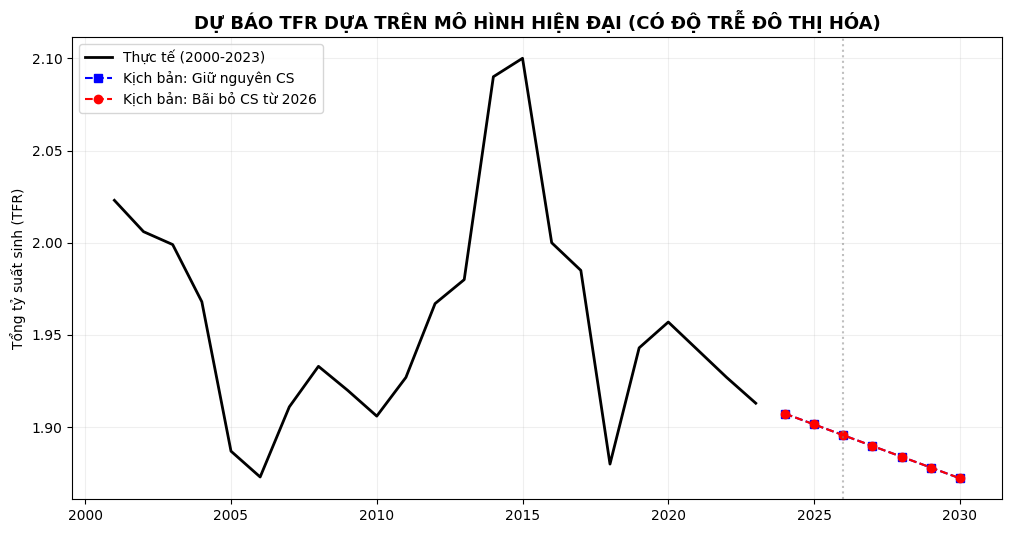


BẢNG DỰ BÁO CHI TIẾT:
 Năm  TFR (Giữ)  TFR (Bãi bỏ)  Chênh lệch
2024     1.9073        1.9073         0.0
2025     1.9015        1.9015         0.0
2026     1.8957        1.8957        -0.0
2027     1.8898        1.8898        -0.0
2028     1.8840        1.8840        -0.0
2029     1.8781        1.8781        -0.0
2030     1.8723        1.8723        -0.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

# 1. NẠP DỮ LIỆU VÀ TIỀN XỬ LÝ THEO MÔ HÌNH 2 (2000-2023)
df = pd.read_excel("data.xlsx")

# Lọc khung thời gian hiện đại (Mô hình 2) để tránh sai lệch điểm gãy cấu trúc
train_df = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)].copy()

# Tạo biến trễ 1 năm cho Đô thị hóa (d_UP_lag1) theo kết quả thực nghiệm
train_df['UP_lag1'] = train_df['UP'].shift(1)

# Do có biến trễ, năm đầu tiên (2000) sẽ bị NaN -> Loại bỏ để sạch dữ liệu
train_df = train_df.dropna(subset=['TF', 'UP_lag1', 'Hexp', 'LF'])

# Khai báo các biến ngoại sinh (Dựa trên Mô hình 2)
# Lưu ý: Policy vẫn được giữ để mô phỏng kịch bản bãi bỏ
features = ['Policy', 'UP_lag1', 'Hexp', 'LF']
y_train = train_df['TF']
X_train = train_df[features]

# 2. HUẤN LUYỆN MÔ HÌNH ARIMAX
# Ta để d=1 để tương ứng với việc dữ liệu đã được xử lý sai phân (d_) trong nghiên cứu
model_arimax = auto_arima(y_train, X=X_train, 
                          start_p=1, start_q=1,
                          max_p=3, max_q=3, d=1, 
                          seasonal=False, stepwise=True, 
                          suppress_warnings=True)

print("\n" + "="*80)
print("KẾT QUẢ MÔ HÌNH DỰ BÁO (HUẤN LUYỆN TRÊN DỮ LIỆU HIỆN ĐẠI 2000-2023)")
print("="*80)
print(model_arimax.summary())

# 3. THIẾT LẬP KỊCH BẢN TƯƠNG LAI (2024 - 2030)
future_years = np.arange(2024, 2031)
n = len(future_years)

# Hàm tính toán giá trị tương lai (Duy trì quán tính tăng trưởng)
def get_future_trend(col_name, periods):
    last_val = train_df[col_name].iloc[-1]
    avg_growth = train_df[col_name].diff().mean()
    return [last_val + avg_growth * i for i in range(1, periods + 1)]

f_up_raw = get_future_trend('UP', n)
# Biến trễ cho tương lai: Giá trị trễ của 2024 chính là thực tế 2023
f_up_lag1 = [train_df['UP'].iloc[-1]] + f_up_raw[:-1] 

f_hexp = get_future_trend('Hexp', n)
f_lf = get_future_trend('LF', n)

# --- KỊCH BẢN A: GIỮ NGUYÊN CHÍNH SÁCH (Policy = 1) ---
X_future_keep = pd.DataFrame({
    'Policy': [1]*n, 
    'UP_lag1': f_up_lag1, 
    'Hexp': f_hexp, 
    'LF': f_lf
}, index=future_years)
forecast_keep = model_arimax.predict(n_periods=n, X=X_future_keep)

# --- KỊCH BẢN B: BÃI BỎ CHÍNH SÁCH TỪ 2026 (Policy về 0) ---
X_future_abolish = X_future_keep.copy()
X_future_abolish['Policy'] = [1, 1, 0, 0, 0, 0, 0] 
forecast_abolish = model_arimax.predict(n_periods=n, X=X_future_abolish)

# 4. VẼ BIỂU ĐỒ SO SÁNH
plt.figure(figsize=(12, 6))
plt.plot(train_df['Year'], train_df['TF'], label='Thực tế (2000-2023)', color='black', lw=2)
plt.plot(future_years, forecast_keep, label='Kịch bản: Giữ nguyên CS', color='blue', ls='--', marker='s')
plt.plot(future_years, forecast_abolish, label='Kịch bản: Bãi bỏ CS từ 2026', color='red', ls='--', marker='o')

plt.axvline(x=2026, color='gray', linestyle=':', alpha=0.5)
plt.title('DỰ BÁO TFR DỰA TRÊN MÔ HÌNH HIỆN ĐẠI (CÓ ĐỘ TRỄ ĐÔ THỊ HÓA)', fontsize=13, fontweight='bold')
plt.ylabel('Tổng tỷ suất sinh (TFR)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 5. XUẤT BẢNG SỐ LIỆU
comparison_df = pd.DataFrame({
    'Năm': future_years,
    'TFR (Giữ)': forecast_keep.values,
    'TFR (Bãi bỏ)': forecast_abolish.values,
    'Chênh lệch': (forecast_abolish - forecast_keep).values
}).round(4)

print("\nBẢNG DỰ BÁO CHI TIẾT:")
print(comparison_df.to_string(index=False))

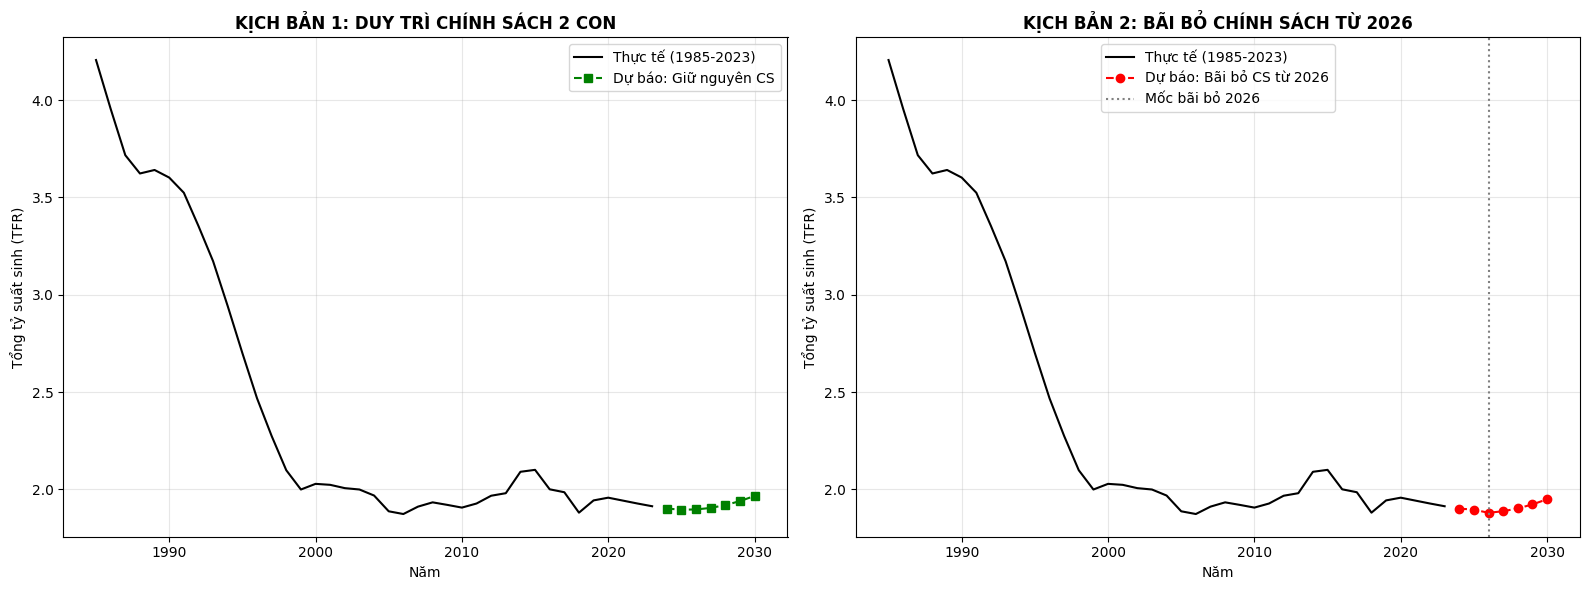


BẢNG SO SÁNH KẾT QUẢ DỰ BÁO:
 Năm  TFR (Giữ CS)  TFR (Bãi bỏ CS)  Chênh lệch
2024         1.901            1.901       0.000
2025         1.895            1.895       0.000
2026         1.896            1.879      -0.017
2027         1.904            1.887      -0.017
2028         1.919            1.902      -0.017
2029         1.939            1.922      -0.017
2030         1.966            1.949      -0.017


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

# 1. NẠP VÀ CHUẨN BỊ DỮ LIỆU
df = pd.read_excel("data.xlsx")
df['Policy_1993'] = np.where(df['Year'] >= 1993, 1, 0)

train_df = df[(df['Year'] >= 1985) & (df['Year'] <= 2023)].copy()
train_df = train_df.dropna(subset=['TF', 'Policy_1993', 'UP'])

y_train = train_df['TF']
X_train = train_df[['Policy_1993', 'UP']]

# 2. HUẤN LUYỆN MÔ HÌNH
model_arimax = auto_arima(y_train, X=X_train, 
                          seasonal=False, stepwise=True, 
                          suppress_warnings=True)

# 3. THIẾT LẬP KỊCH BẢN
future_years = np.arange(2024, 2031)
n_periods = len(future_years)

last_up = train_df['UP'].iloc[-1]
avg_up_growth = train_df['UP'].diff().mean()
future_up = [last_up + avg_up_growth * i for i in range(1, n_periods + 1)]

# Kịch bản 1: Giữ nguyên (Policy = 1)
X_future_keep = pd.DataFrame({'Policy_1993': [1]*n_periods, 'UP': future_up}, index=future_years)
forecast_keep = model_arimax.predict(n_periods=n_periods, X=X_future_keep)

# Kịch bản 2: Bãi bỏ từ 2026 (Policy = 0)
policy_abolish = [1, 1, 0, 0, 0, 0, 0]
X_future_abolish = pd.DataFrame({'Policy_1993': policy_abolish, 'UP': future_up}, index=future_years)
forecast_abolish = model_arimax.predict(n_periods=n_periods, X=X_future_abolish)

# 4. VẼ 2 BIỂU ĐỒ RIÊNG BIỆT (Dùng Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) # 1 hàng, 2 cột

# --- Biểu đồ 1: Giữ nguyên chính sách ---
ax1.plot(train_df['Year'], train_df['TF'], color='black', label='Thực tế (1985-2023)')
ax1.plot(future_years, forecast_keep, color='green', linestyle='--', marker='s', label='Dự báo: Giữ nguyên CS')
ax1.set_title('KỊCH BẢN 1: DUY TRÌ CHÍNH SÁCH 2 CON', fontsize=12, fontweight='bold')
ax1.set_xlabel('Năm')
ax1.set_ylabel('Tổng tỷ suất sinh (TFR)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- Biểu đồ 2: Bãi bỏ chính sách ---
ax2.plot(train_df['Year'], train_df['TF'], color='black', label='Thực tế (1985-2023)')
ax2.plot(future_years, forecast_abolish, color='red', linestyle='--', marker='o', label='Dự báo: Bãi bỏ CS từ 2026')
ax2.axvline(x=2026, color='gray', linestyle=':', label='Mốc bãi bỏ 2026')
ax2.set_title('KỊCH BẢN 2: BÃI BỎ CHÍNH SÁCH TỪ 2026', fontsize=12, fontweight='bold')
ax2.set_xlabel('Năm')
ax2.set_ylabel('Tổng tỷ suất sinh (TFR)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 5. IN BẢNG SO SÁNH SỐ LIỆU
comparison_df = pd.DataFrame({
    'Năm': future_years,
    'TFR (Giữ CS)': np.round(forecast_keep, 3),
    'TFR (Bãi bỏ CS)': np.round(forecast_abolish, 3),
    'Chênh lệch': np.round(forecast_abolish - forecast_keep, 3)
})

print("\nBẢNG SO SÁNH KẾT QUẢ DỰ BÁO:")
print(comparison_df.to_string(index=False))

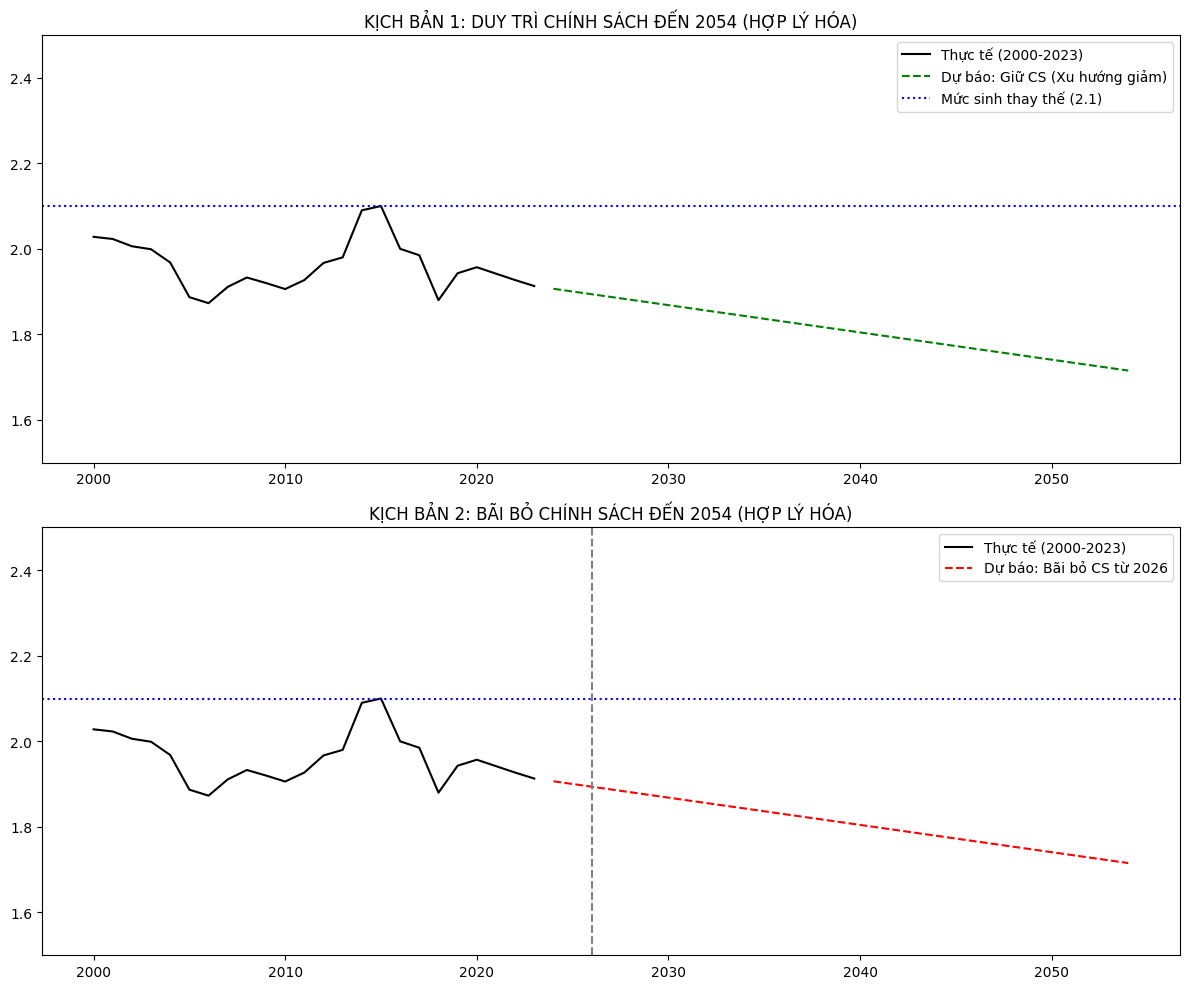

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

# 1. NẠP DỮ LIỆU VÀ CHUẨN BỊ (Dùng dữ liệu hiện đại từ 2000 để sát thực tế)
df = pd.read_excel("data.xlsx")
# Giả sử các cột: Year, TF, Policy, UP, LF, GDP, Hexp
train_df = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)].copy()

# 2. KHAI BÁO BIẾN (Chọn các biến có tác động kìm hãm)
features = ['Policy', 'UP', 'LF'] 
y_train = train_df['TF']
X_train = train_df[features]

# 3. HUẤN LUYỆN MÔ HÌNH VỚI RÀNG BUỘC (Sử dụng d=1 để tránh drift đi lên)
model_arimax = auto_arima(y_train, X=X_train, 
                          d=1,           # Quan trọng: Lấy sai phân để dự báo ổn định
                          stationary=False,
                          seasonal=False, 
                          stepwise=True, 
                          suppress_warnings=True)

# 4. THIẾT LẬP KỊCH BẢN 2024 - 2054
future_years = np.arange(2024, 2055)
n = len(future_years)

# Giả định đô thị hóa tiếp tục tăng (nhưng làm giảm TFR)
last_up = train_df['UP'].iloc[-1]
avg_up_growth = train_df['UP'].diff().mean()
future_up = [last_up + avg_up_growth * i for i in range(1, n + 1)]

# Giả định lực lượng lao động ổn định
f_lf = [train_df['LF'].iloc[-1]] * n

# Tạo X_future cho 2 kịch bản
X_future_keep = pd.DataFrame({'Policy': [1]*n, 'UP': future_up, 'LF': f_lf}, index=future_years)
X_future_abolish = pd.DataFrame({'Policy': [1 if yr < 2026 else 0 for yr in future_years], 
                                 'UP': future_up, 'LF': f_lf}, index=future_years)

# 5. DỰ BÁO
forecast_keep = model_arimax.predict(n_periods=n, X=X_future_keep)
forecast_abolish = model_arimax.predict(n_periods=n, X=X_future_abolish)

# 6. VẼ BIỂU ĐỒ (Tách 2 kịch bản)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Kịch bản 1: Giữ chính sách (Thường sẽ đi xuống dần do UP tăng)
ax1.plot(train_df['Year'], train_df['TF'], color='black', label='Thực tế (2000-2023)')
ax1.plot(future_years, forecast_keep, color='green', linestyle='--', label='Dự báo: Giữ CS (Xu hướng giảm)')
ax1.set_ylim(1.5, 2.5) # Giới hạn trục Y để thấy rõ dao động quanh mức 2.0
ax1.axhline(y=2.1, color='blue', linestyle=':', label='Mức sinh thay thế (2.1)')
ax1.set_title('KỊCH BẢN 1: DUY TRÌ CHÍNH SÁCH ĐẾN 2054 (HỢP LÝ HÓA)')
ax1.legend()

# Kịch bản 2: Bãi bỏ chính sách (Sẽ nhích nhẹ rồi lại giảm theo UP)
ax2.plot(train_df['Year'], train_df['TF'], color='black', label='Thực tế (2000-2023)')
ax2.plot(future_years, forecast_abolish, color='red', linestyle='--', label='Dự báo: Bãi bỏ CS từ 2026')
ax2.set_ylim(1.5, 2.5)
ax2.axhline(y=2.1, color='blue', linestyle=':')
ax2.axvline(x=2026, color='gray', linestyle='--')
ax2.set_title('KỊCH BẢN 2: BÃI BỎ CHÍNH SÁCH ĐẾN 2054 (HỢP LÝ HÓA)')
ax2.legend()

plt.tight_layout()
plt.show()